In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.constants as pc
import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.visualization import AsinhStretch, ImageNormalize, ManualInterval
import os

FILTERS =["F606W", "F814W","F115W", "F150W", "F200W", "F277W", "F356W", "F444W"]
# Individual filters increasing in wavelength
# Stacked filters are not useful for Sersíc fitting

CUTOUT_SIZES = ["0.96as", "3.0as"]
# The side lenghts of the plot out squares (each pixel is 0.03 as across) 

BROAD_LINE_DATA_PATH = "/nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits"



In [2]:
def open_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)

        """
        print("\nColumns:")
        print(tbl.colnames)
        """
        return tbl

In [3]:
def cutout_plot(BROAD_LINE_DATA_PATH):

    table = open_table(BROAD_LINE_DATA_PATH)
    # All my raw data on the galaxies
    
    ids = table["SURVEY_ID"]
    surveys = table["SURVEY"]

    for i in range(len(ids)):

        id = ids[i]
        survey = surveys[i]
        # Create an output directory for this galaxy
        #output_dir = f"/nvme/work/scratch/alberttg/Summer_project/Cutouts/{id}"
        #os.makedirs(output_dir, exist_ok=True)  

        for filt in FILTERS:

            if survey in ["CEERSP1", "CEERSP2", "CEERSP3", "CEERSP4", "CEERSP5", "CEERSP6", "CEERSP7", "CEERSP7", "CEERSP8", "CEERSP9", "CEERSP10"]:

                    path = f"/raid/scratch/work/austind/GALFIND_WORK/Cutouts/v14/{survey}/ACS_WFC+NIRCam/0.96as/{filt}/SExtractor2.25.0_rms_F277W+F356W+F444W_(0.32)as/data/{id}.fits"

            if survey in ["PRIMER-COSMOS", "PRIMER-UDS"]:

                    path = f"/raid/scratch/work/austind/GALFIND_WORK/Cutouts/v12_psfmatch_F444W_empirical/{survey}/ACS_WFC+NIRCam/0.96as/{filt}/data_native/{id}.fits"

            if survey in ["JADES-DR3-GS-East", "JADES-DR3-GS-North", "JADES-DR3-GS-South", "JADES-DR3-GS-West", "JADES-DR3-GN-Parallel", "JADES-DR3-GN-PMedium", "JADES-DR3-GN-Deep"]:

                    path = f"/raid/scratch/work/austind/GALFIND_WORK/Cutouts/v13/{survey}/ACS_WFC+NIRCam/0.96as/{filt}/data_native/{id}.fits"

            else:
                    print(f"Galaxy {id} could not be found in these surveys")
                    break

            fig, ax = plt.subplots(figsize=(6,6))
            # open fits file and plot the image
            hdul = fits.open(path)
            data = hdul[1].data

            vmin, vmax = np.percentile(data, (5,99))
            # Maybe change for visualisation

            norm = ImageNormalize(data, interval=ManualInterval(vmin=vmin, vmax=vmax), # automatic contrast (like DS9)
                                  stretch=AsinhStretch())                      
            # Asinh keeps faint structures but becomes log at high flux to show structural differences at centre
            ax.imshow(data, norm=norm, origin="lower", cmap="gray")
            
            # label filt in upper right
            # (0,0) is bottom left
            # (1,1) is top right
            ax.text(0.98, 0.98, f"{filt} {id}", transform=ax.transAxes, ha="right", va="top", fontsize=12, bbox=dict(boxstyle="round,pad=0.3",facecolor="white",edgecolor="black",alpha=0.8))

            ax.set_xticks([])
            ax.set_yticks([])
            # Removes tick marks
            plt.tight_layout()
            plt.show()
            #plt.savefig(os.path.join(output_dir, f"{filt}.png"), dpi=300, bbox_inches="tight")
            plt.close(fig)

Filename: /nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     54   144R x 23C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 18A, 21A, J]   
Galaxy 56116 could not be found in these surveys
Galaxy 221999 could not be found in these surveys
Galaxy 83894 could not be found in these surveys
Galaxy 108492 could not be found in these surveys
Galaxy 14640 could not be found in these surveys
Galaxy 11792 could not be found in these surveys


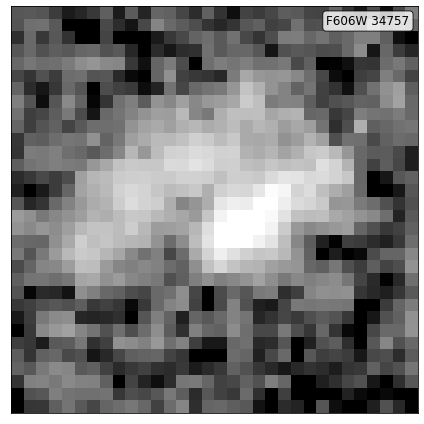

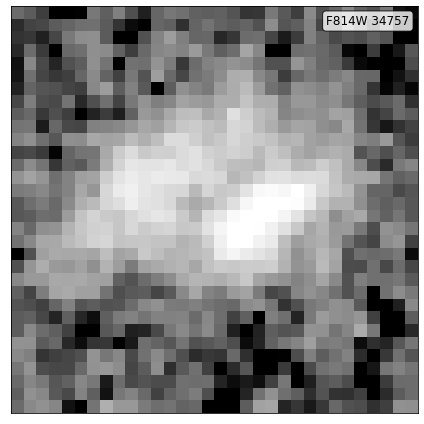

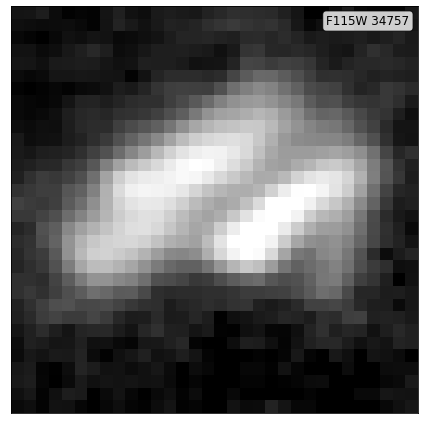

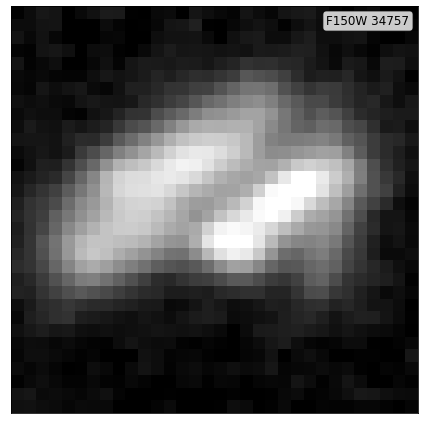

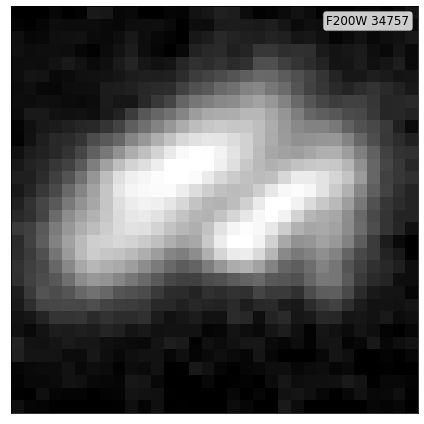

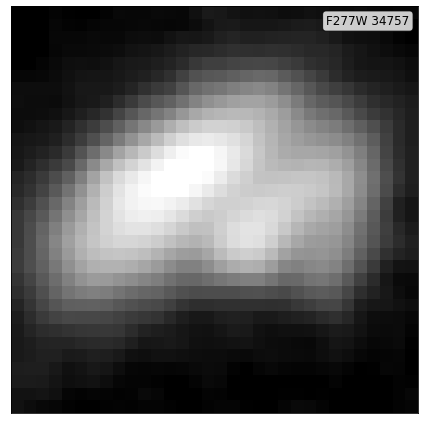

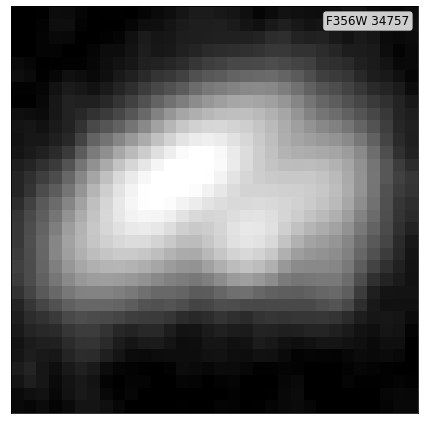

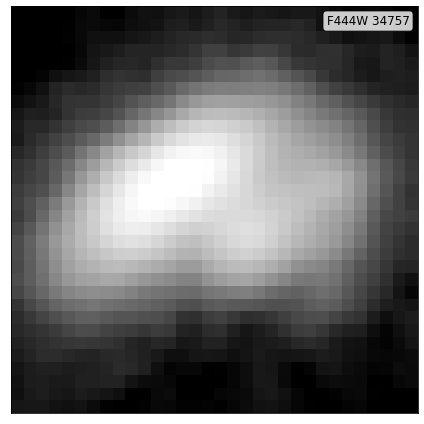

Galaxy 208439 could not be found in these surveys
Galaxy 245058 could not be found in these surveys
Galaxy 69070 could not be found in these surveys
Galaxy 94378 could not be found in these surveys
Galaxy 237731 could not be found in these surveys
Galaxy 130917 could not be found in these surveys


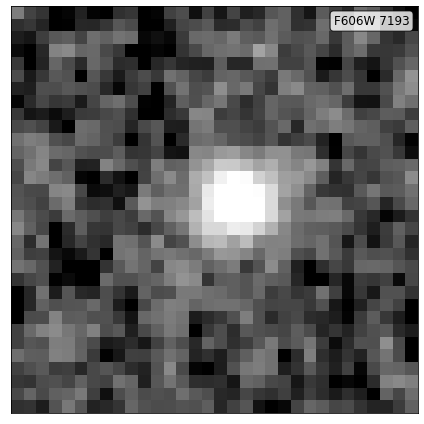

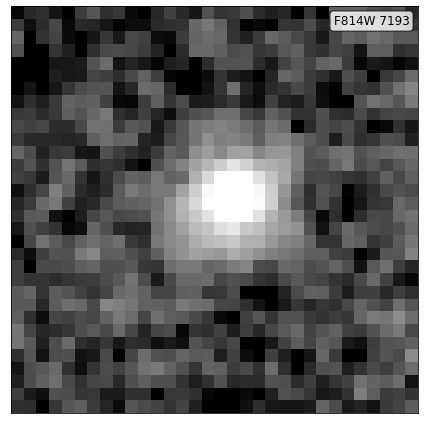

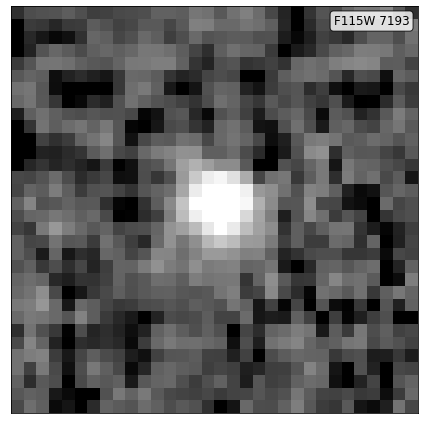

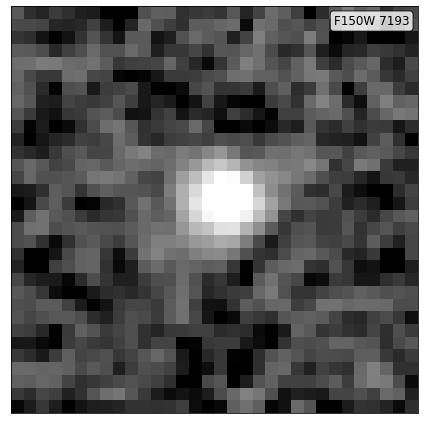

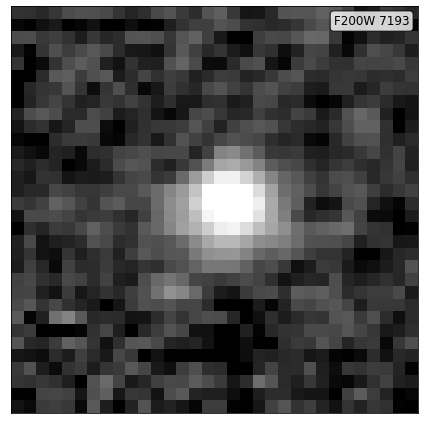

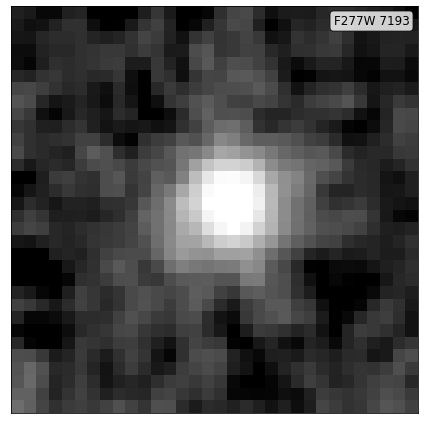

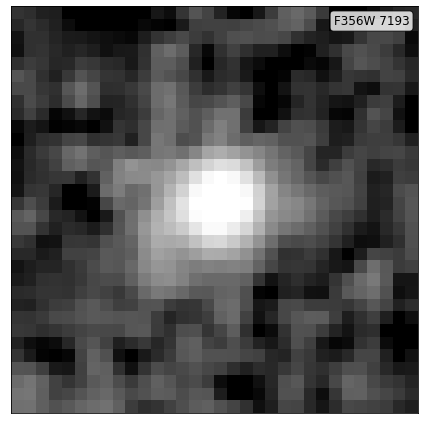

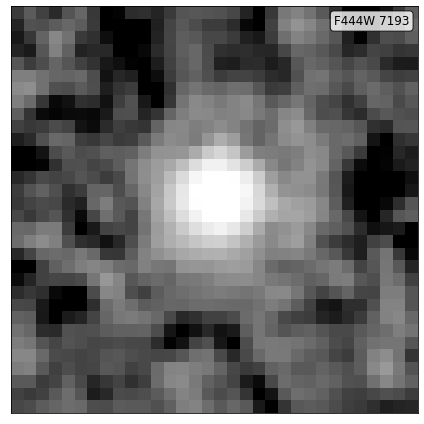

Galaxy 5881 could not be found in these surveys
Galaxy 6122 could not be found in these surveys
Galaxy 3919 could not be found in these surveys
Galaxy 133273 could not be found in these surveys
Galaxy 23392 could not be found in these surveys
Galaxy 93339 could not be found in these surveys
Galaxy 7903 could not be found in these surveys
Galaxy 1444 could not be found in these surveys
Galaxy 104399 could not be found in these surveys
Galaxy 115903 could not be found in these surveys


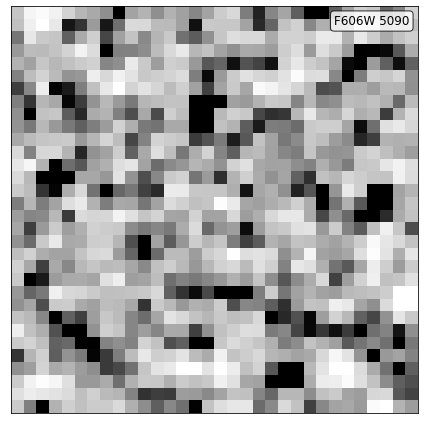

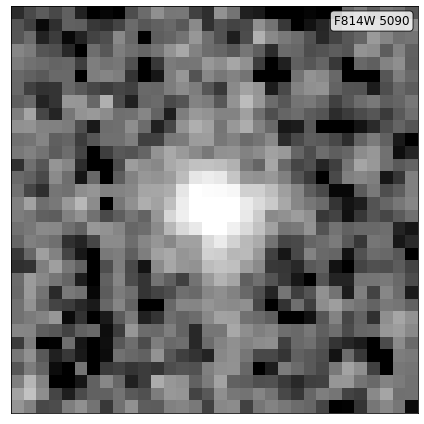

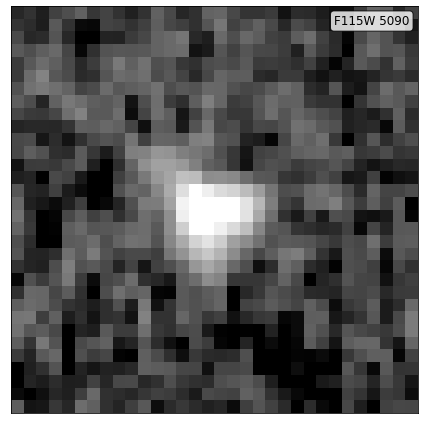

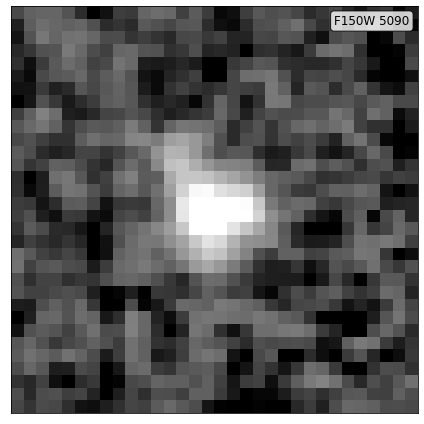

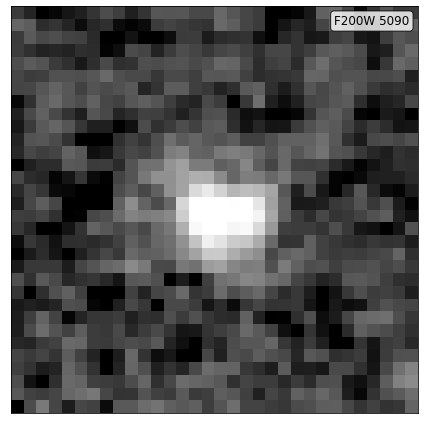

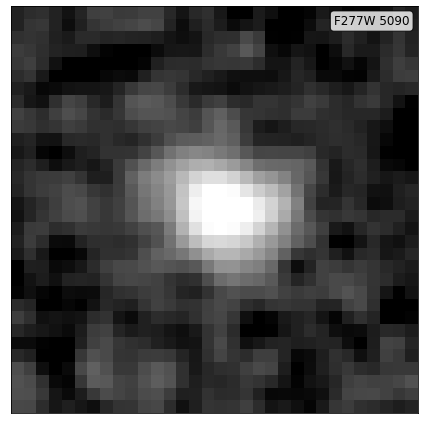

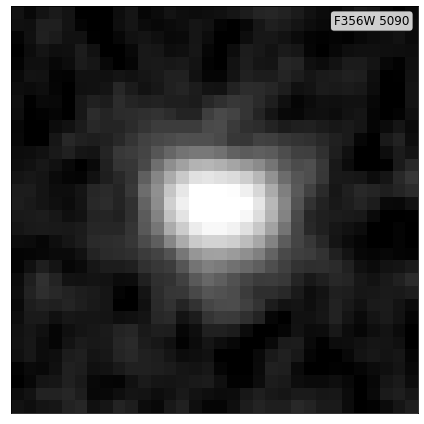

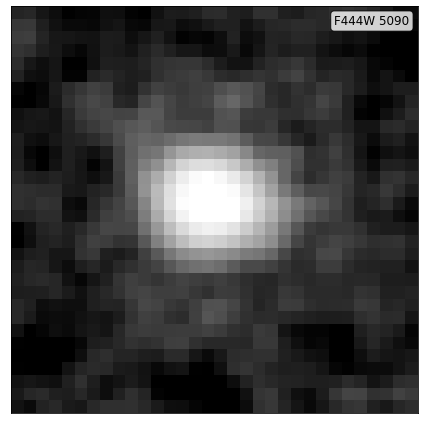

Galaxy 8875 could not be found in these surveys
Galaxy 8153 could not be found in these surveys
Galaxy 5480 could not be found in these surveys
Galaxy 57337 could not be found in these surveys


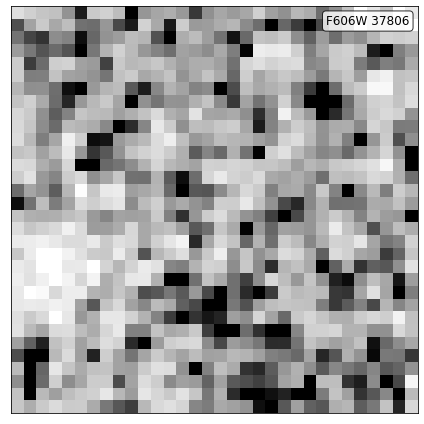

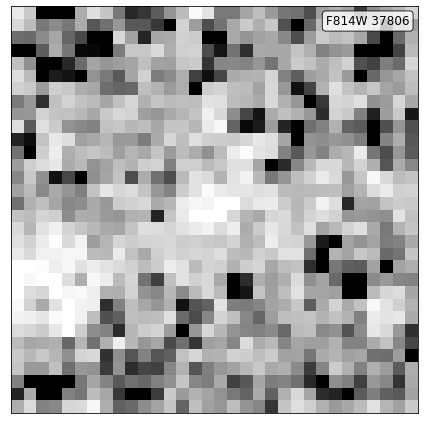

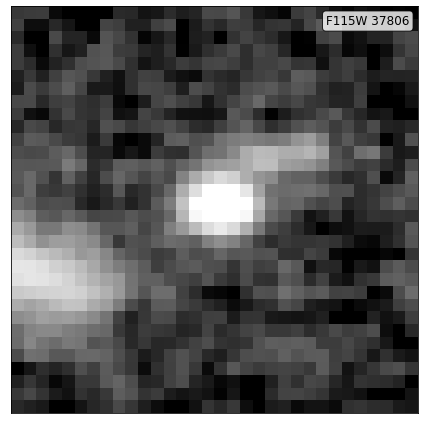

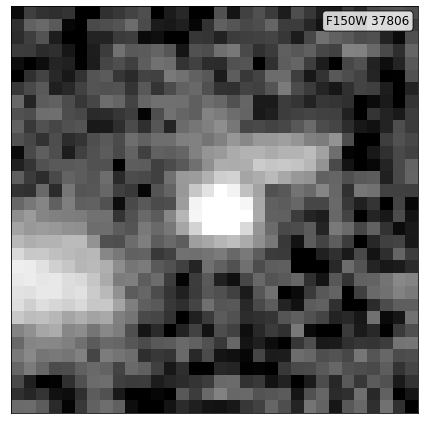

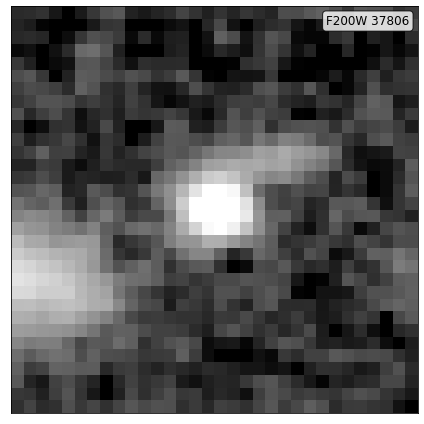

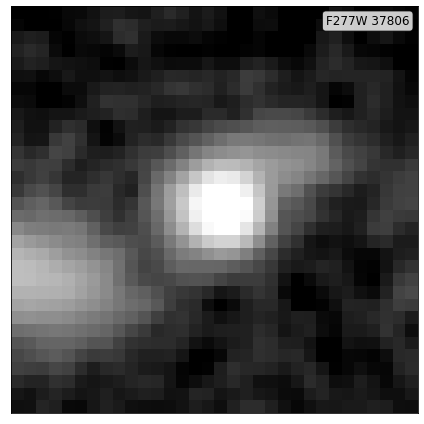

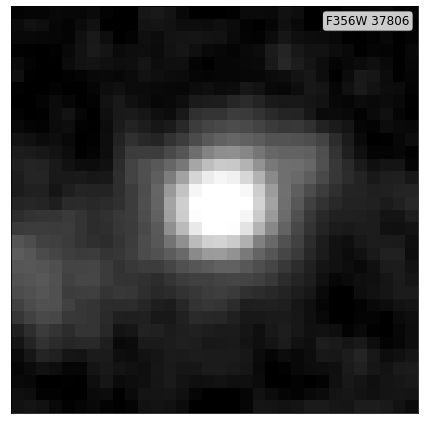

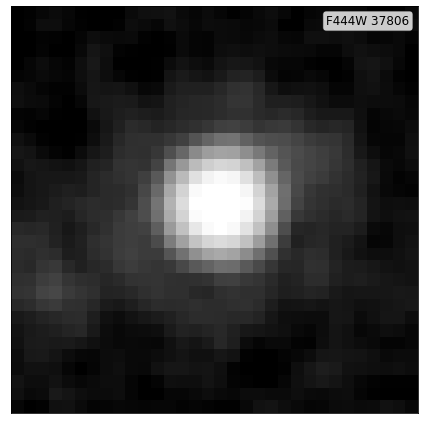

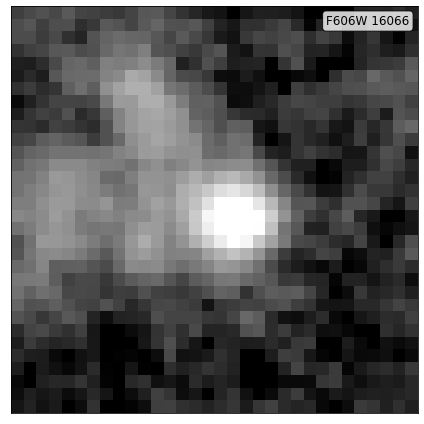

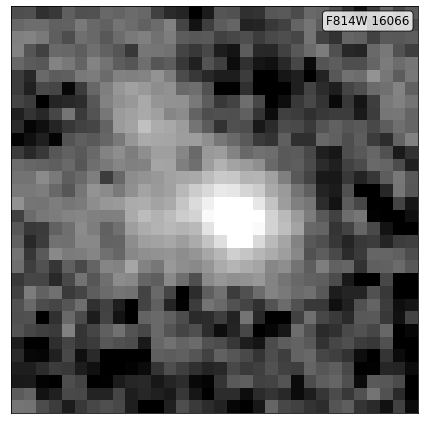

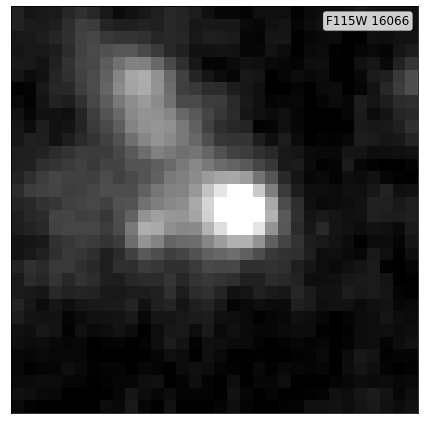

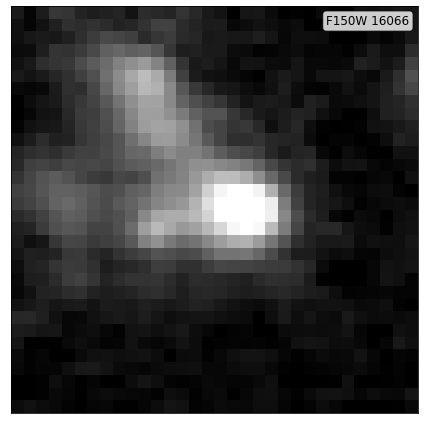

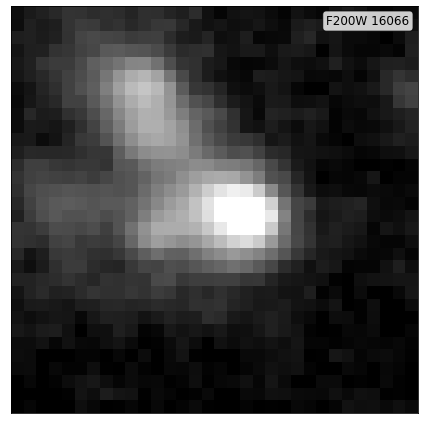

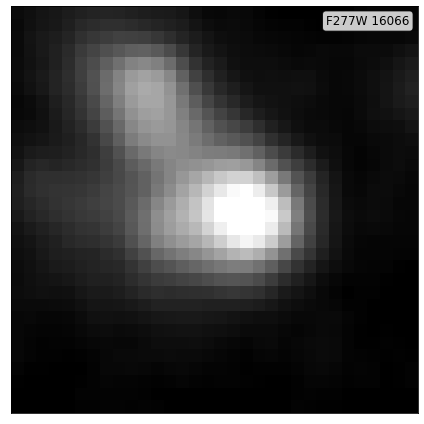

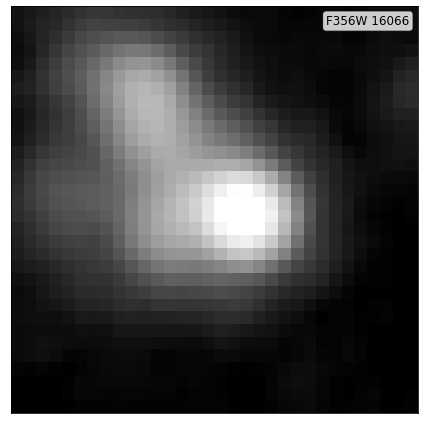

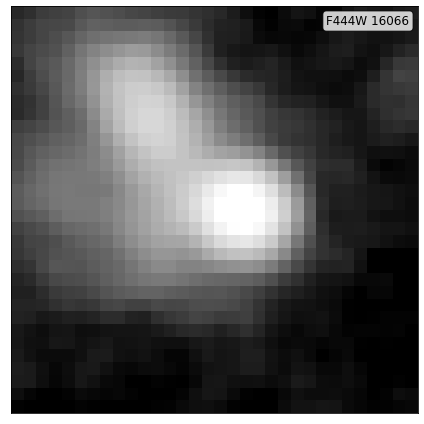

Galaxy 3691 could not be found in these surveys


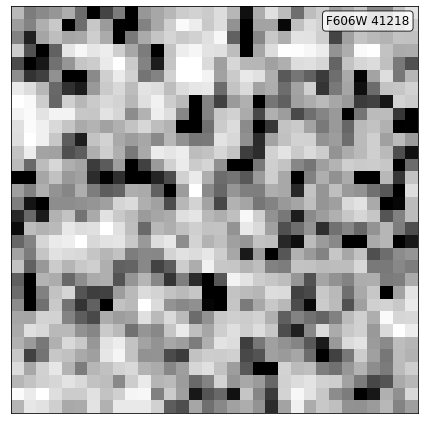

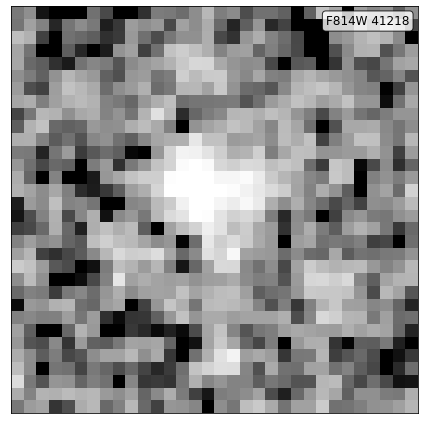

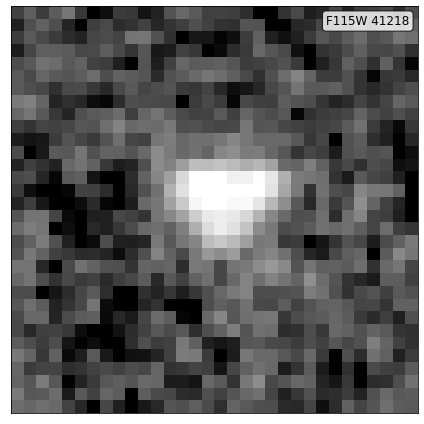

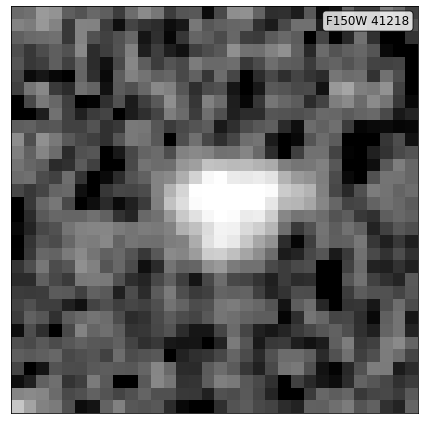

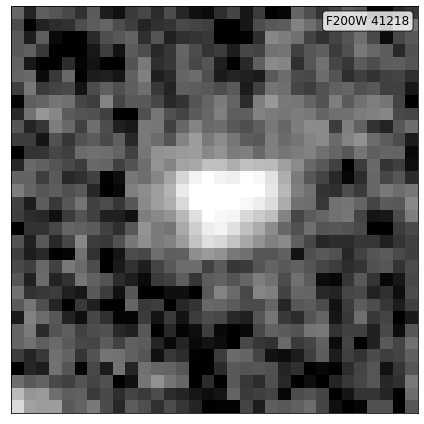

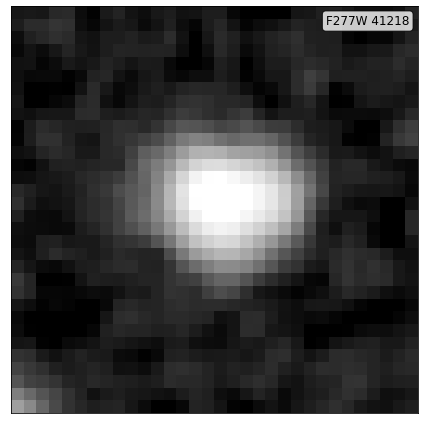

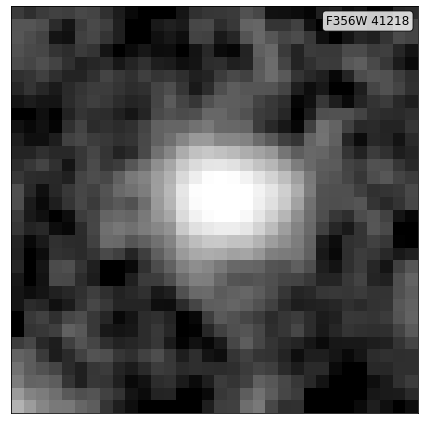

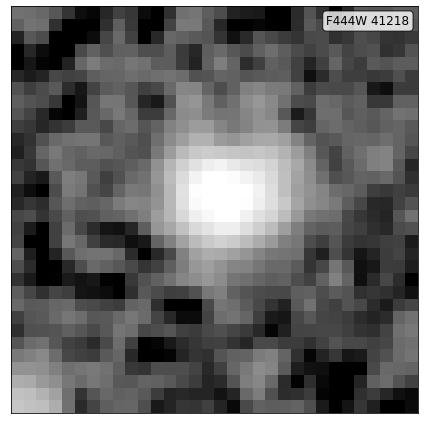

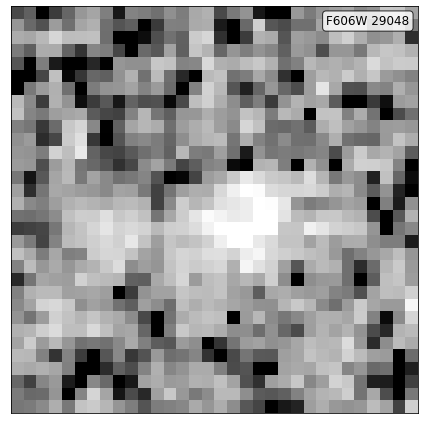

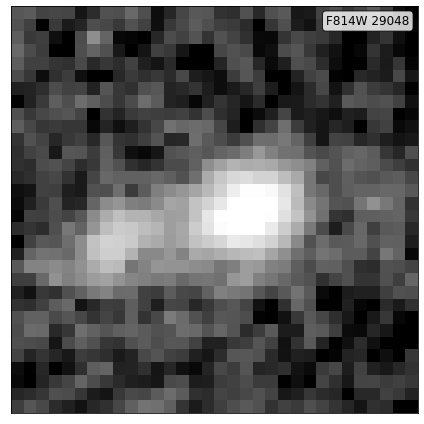

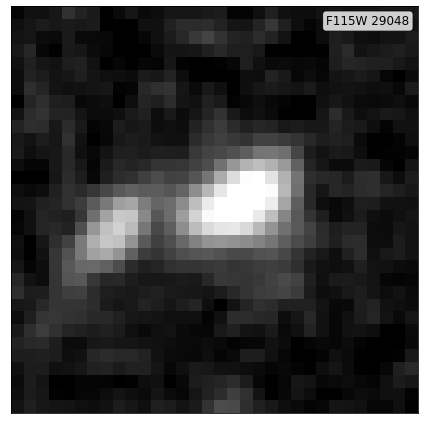

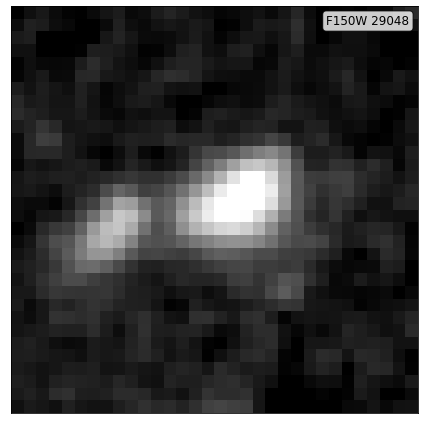

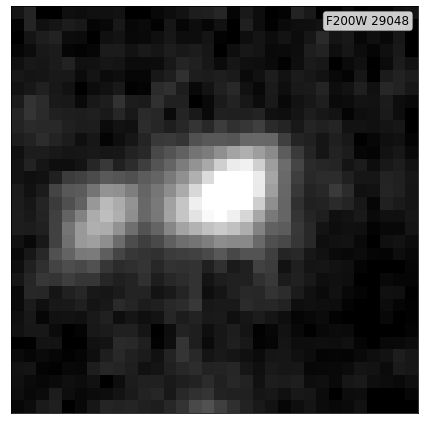

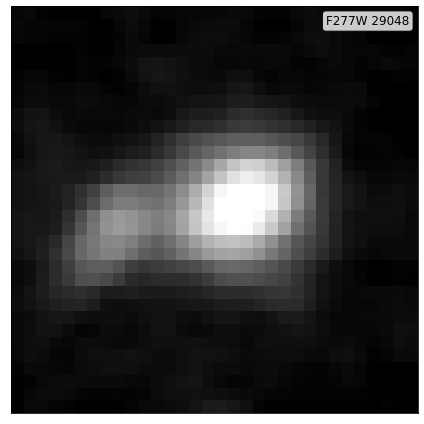

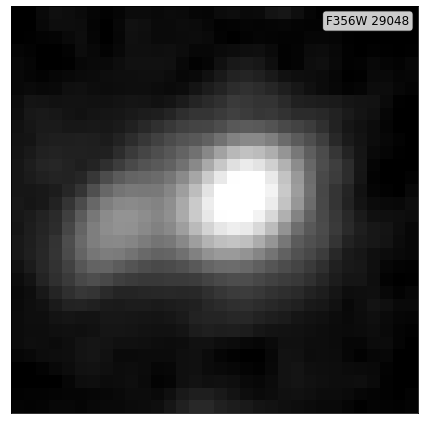

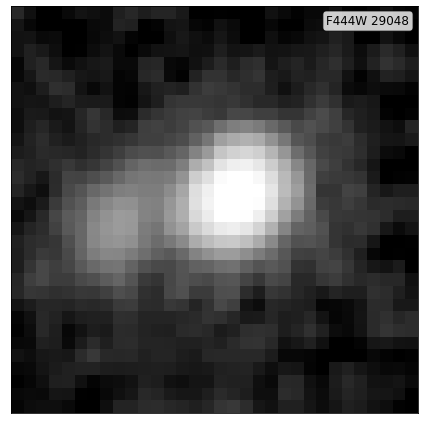

/usr/local/anaconda-python-3.6/lib/python3.6/site-packages/astropy/visualization/mpl_normalize.py:164: RuntimeWarning: invalid value encountered in true_divide
  np.true_divide(values, self.vmax - self.vmin, out=values)


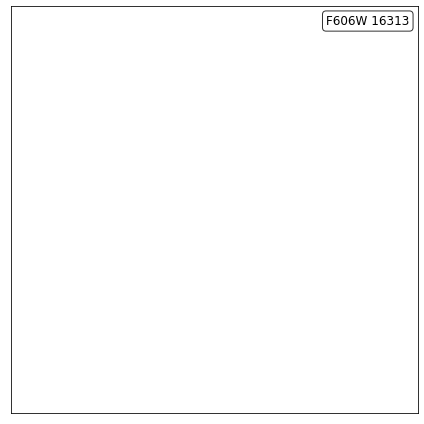

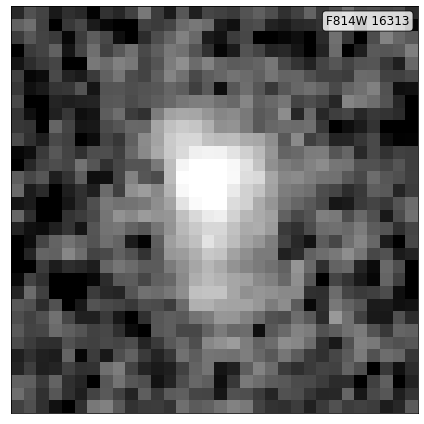

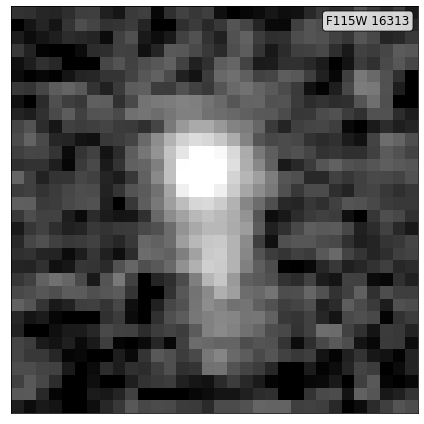

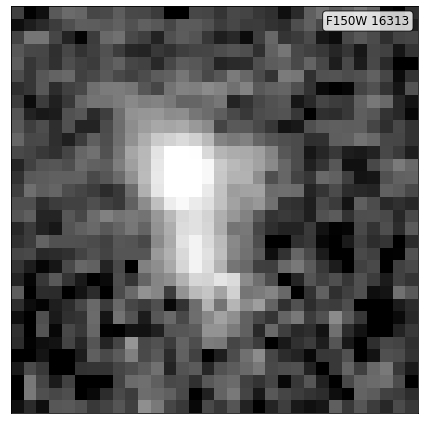

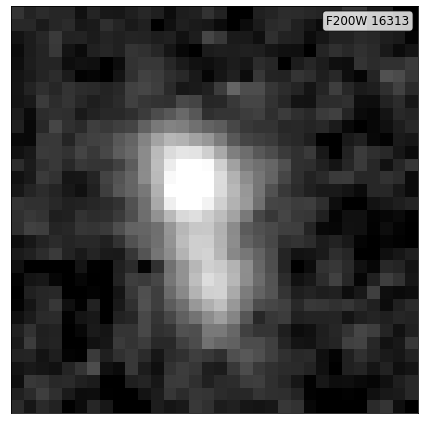

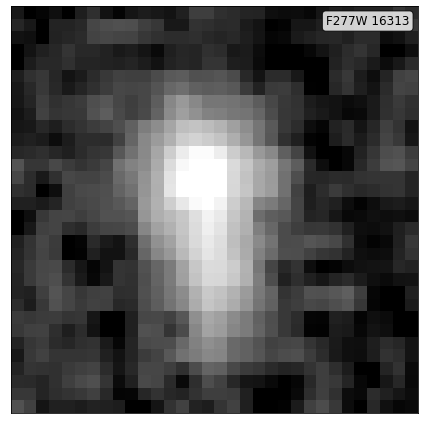

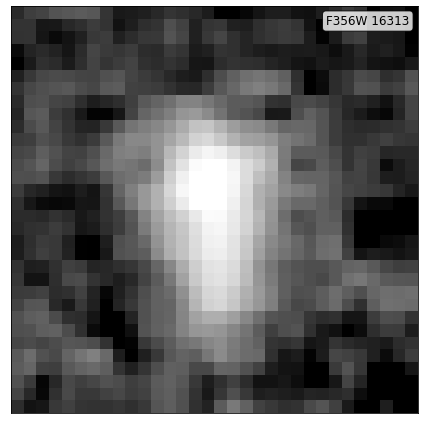

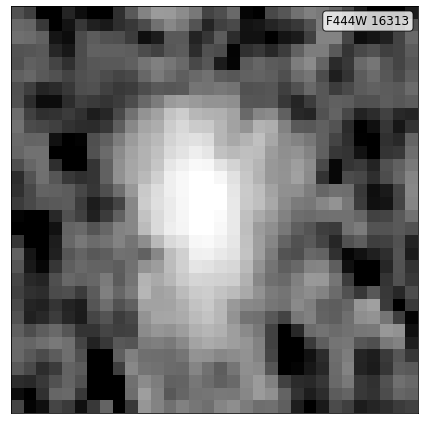

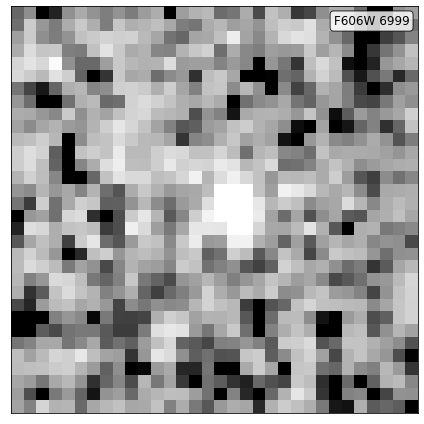

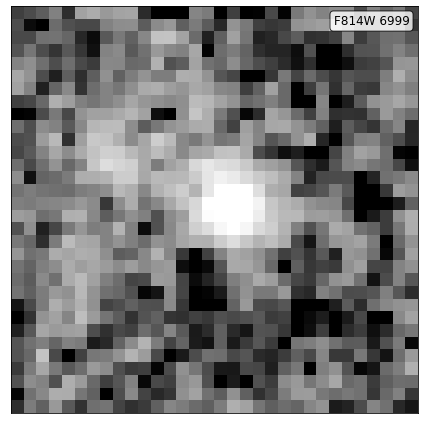

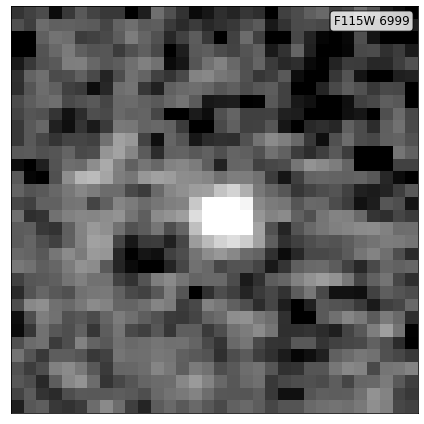

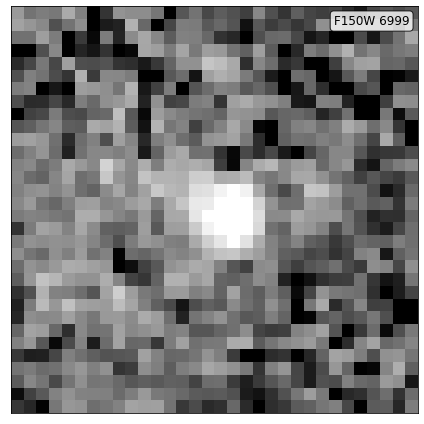

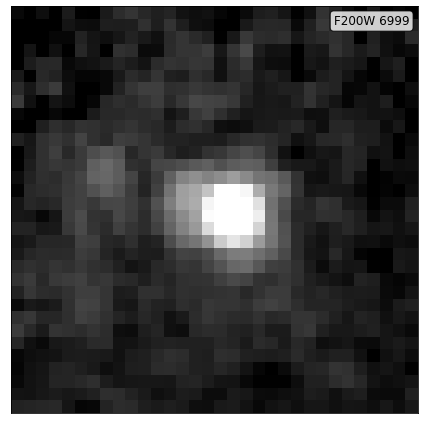

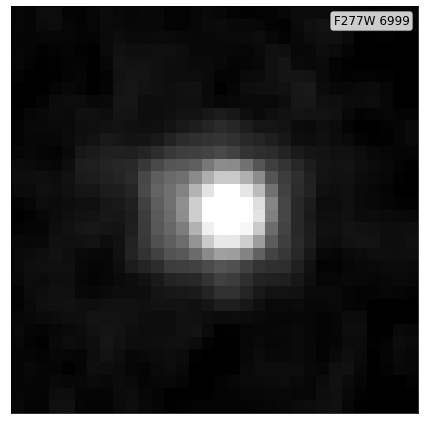

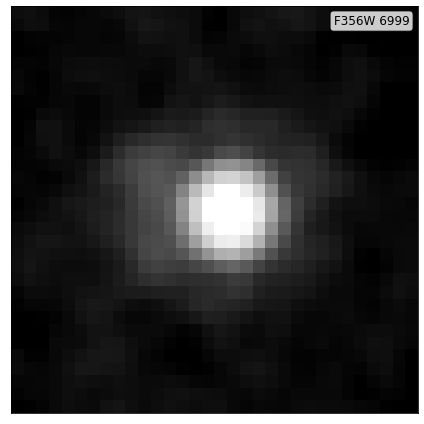

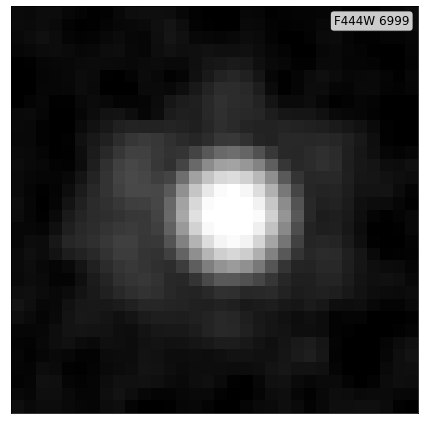

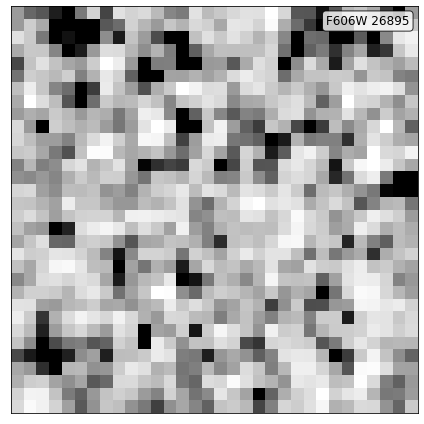

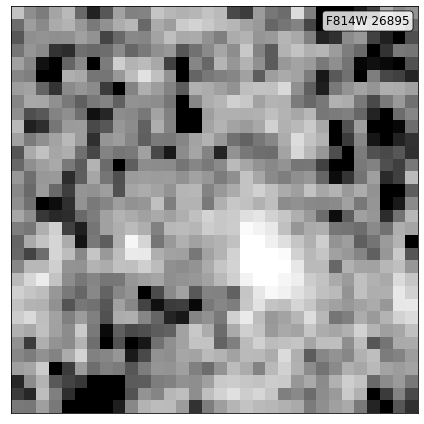

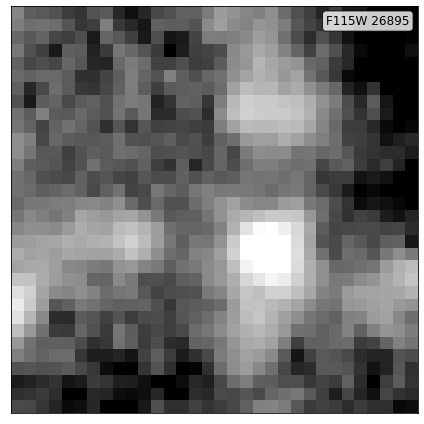

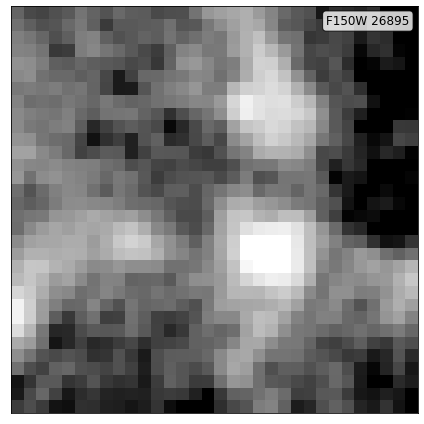

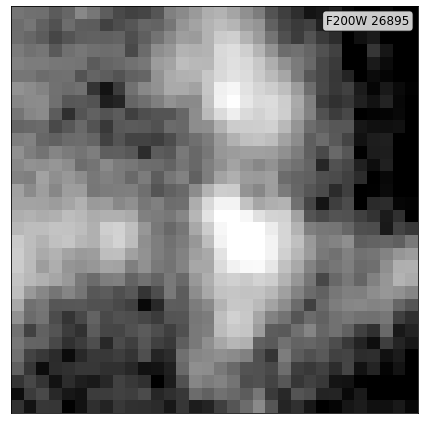

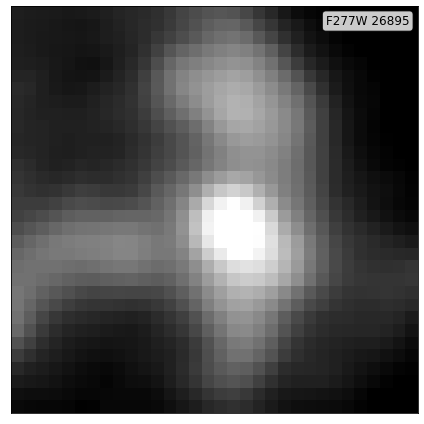

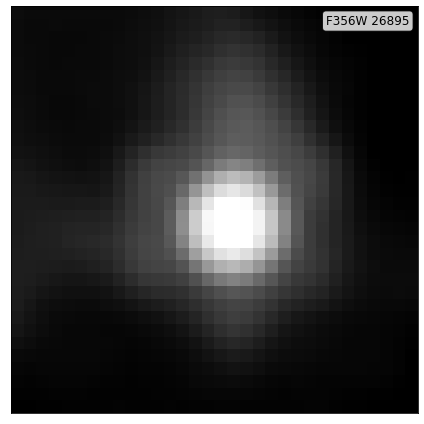

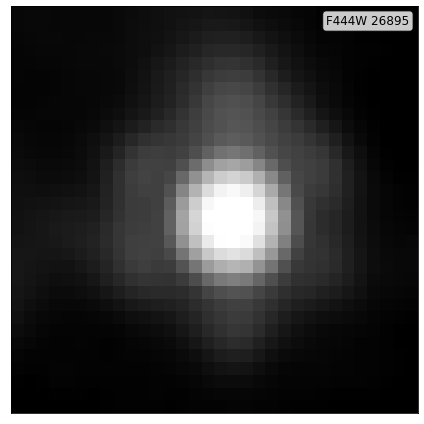

Galaxy 5783 could not be found in these surveys
Galaxy 19882 could not be found in these surveys
Galaxy 33630 could not be found in these surveys
Galaxy 82455 could not be found in these surveys
Galaxy 38176 could not be found in these surveys
Galaxy 72188 could not be found in these surveys
Galaxy 216681 could not be found in these surveys
Galaxy 14150 could not be found in these surveys
Galaxy 12007 could not be found in these surveys
Galaxy 1847 could not be found in these surveys
Galaxy 6191 could not be found in these surveys
Galaxy 16639 could not be found in these surveys


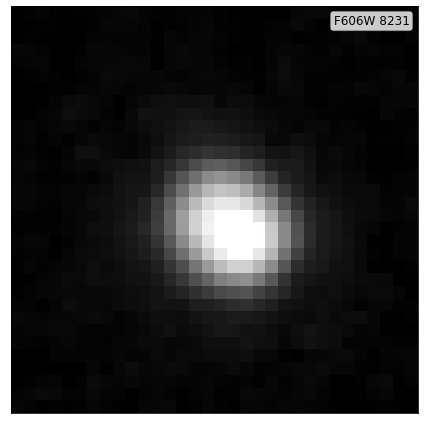

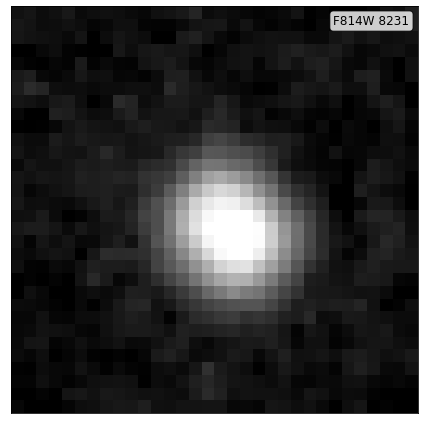

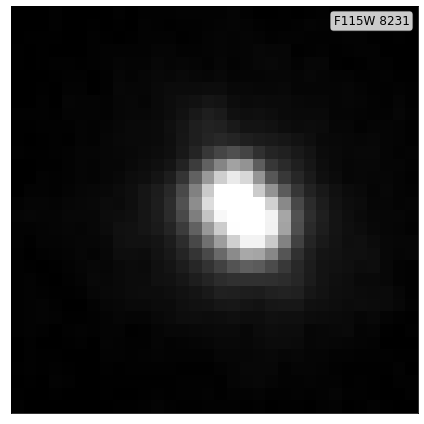

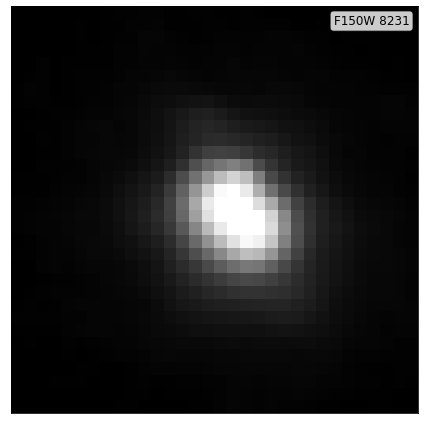

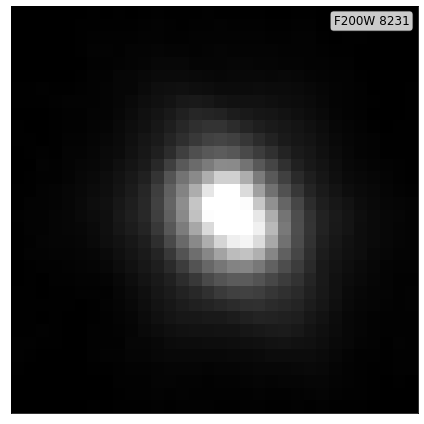

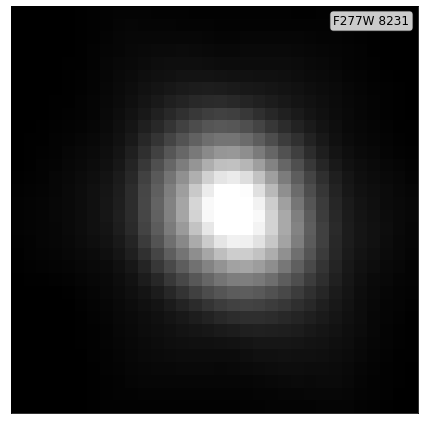

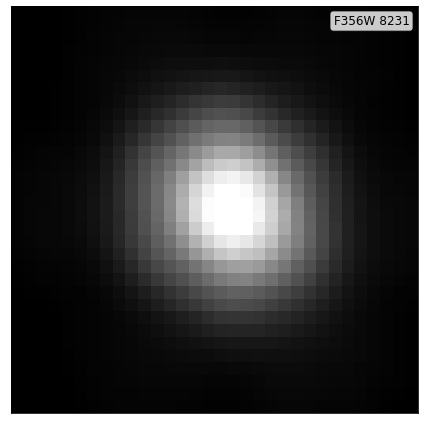

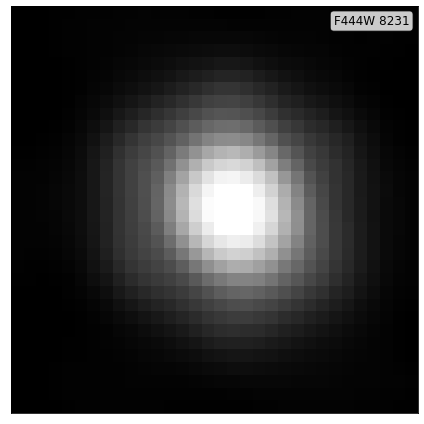

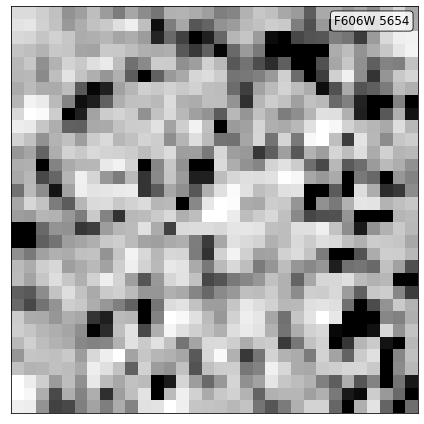

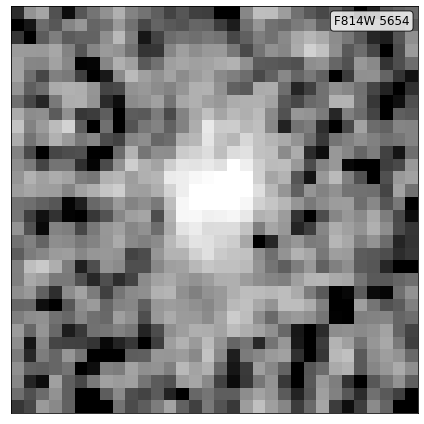

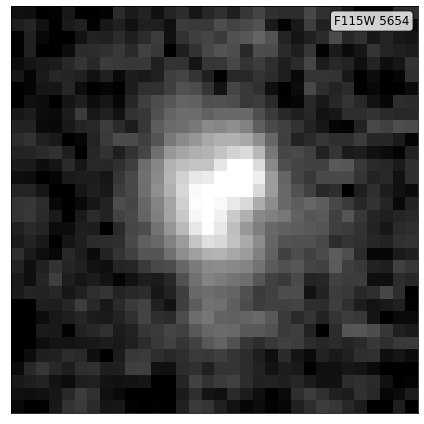

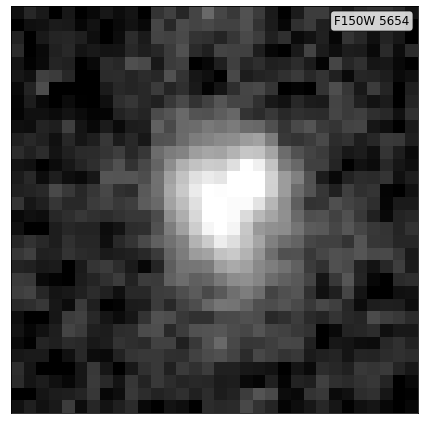

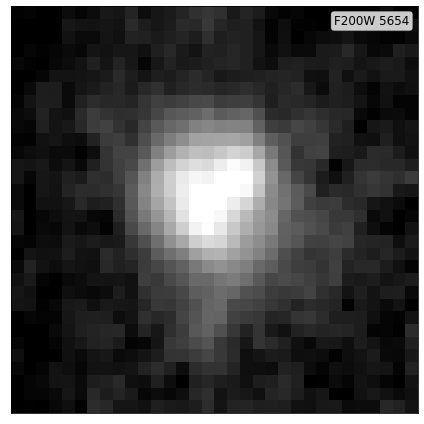

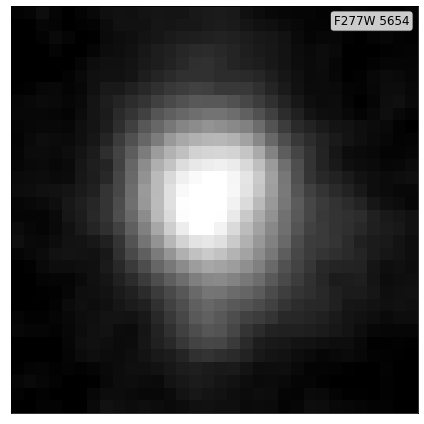

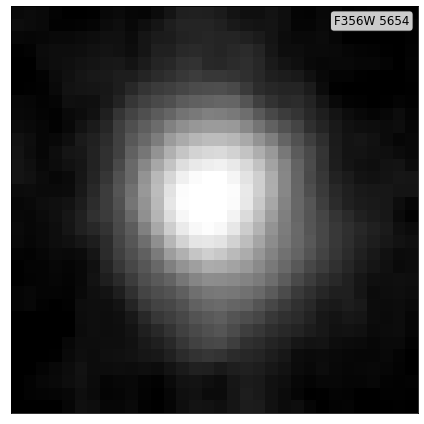

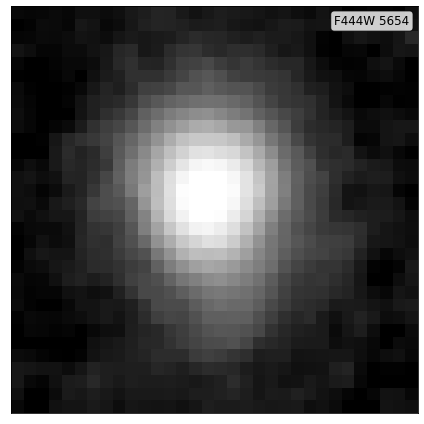

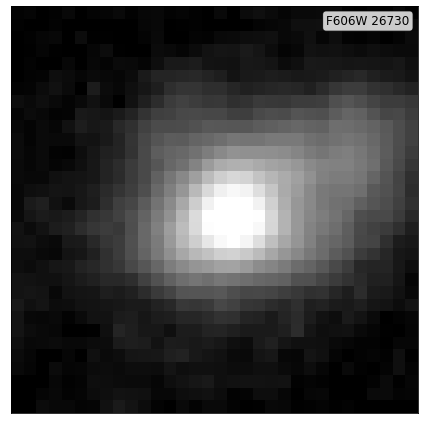

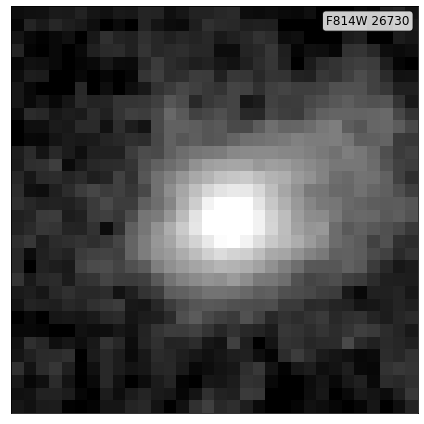

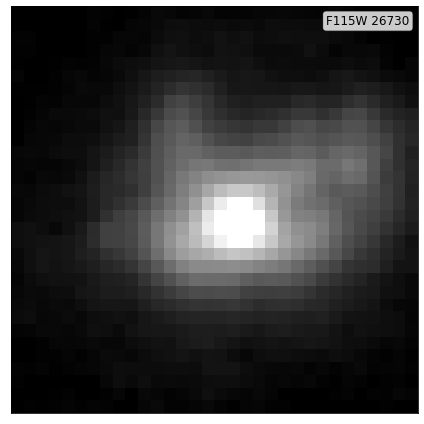

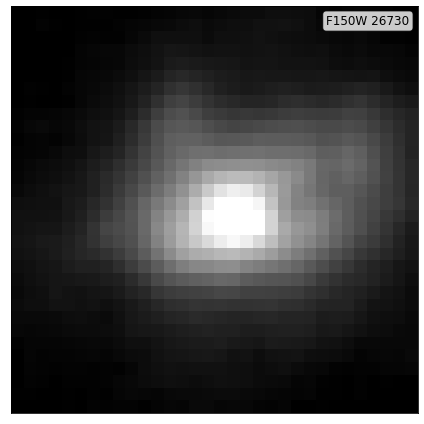

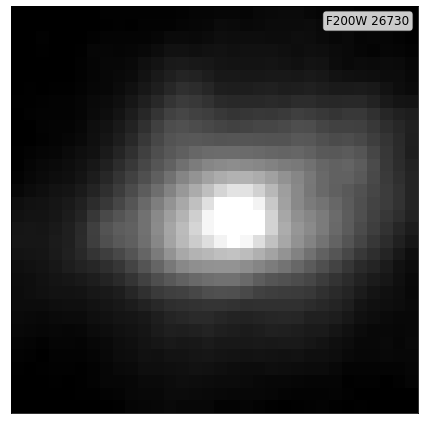

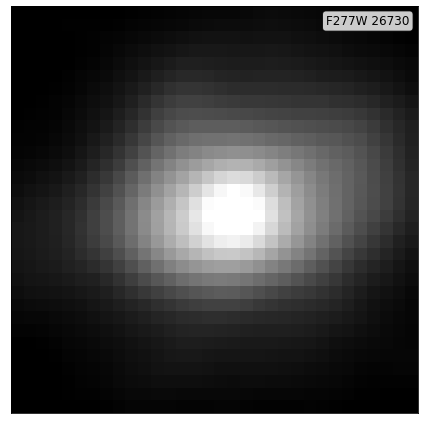

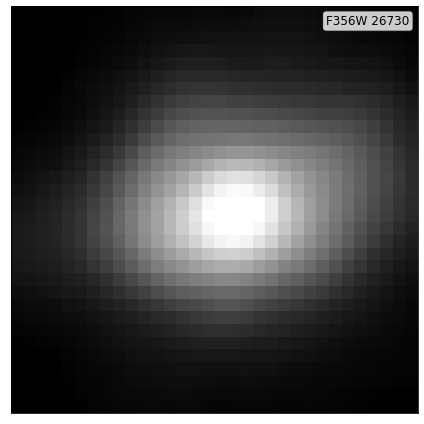

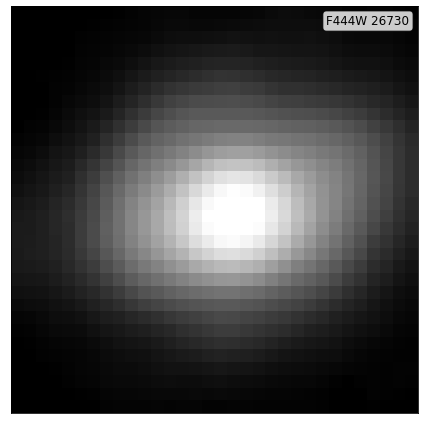

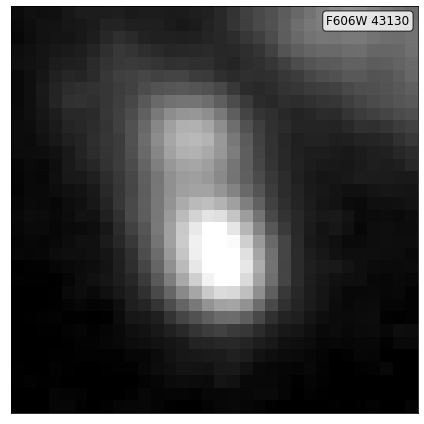

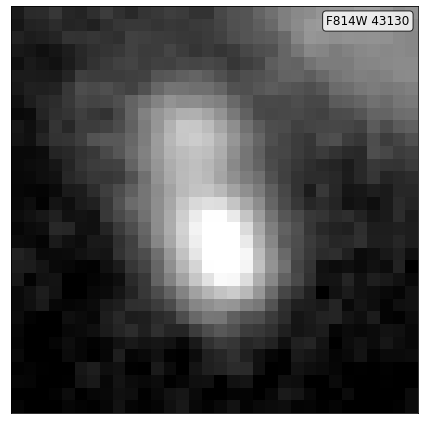

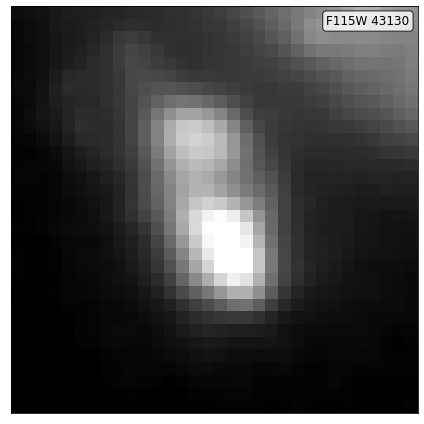

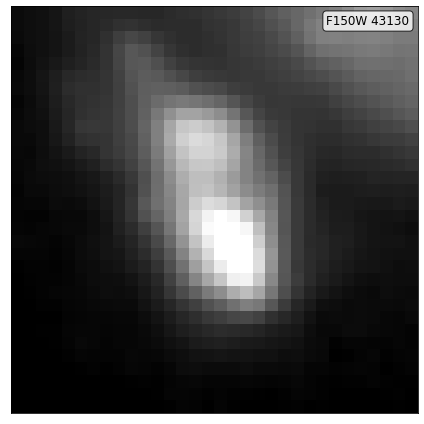

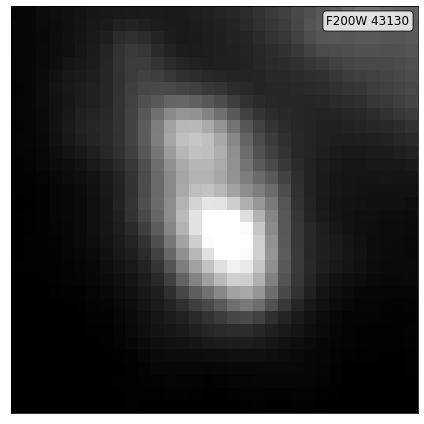

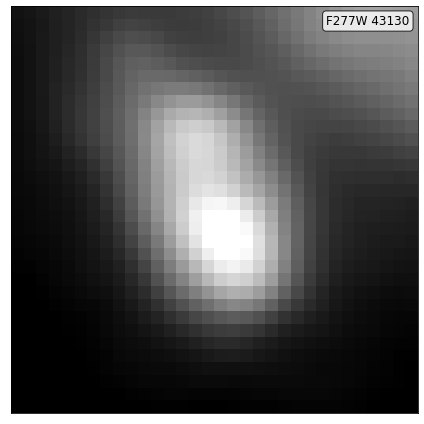

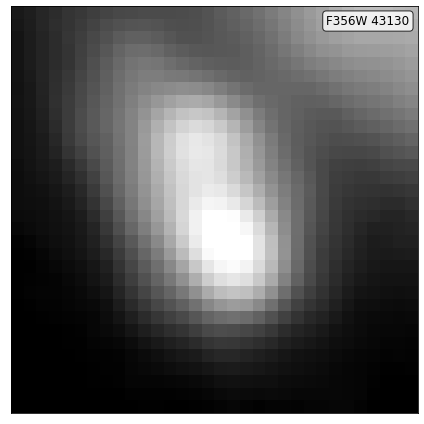

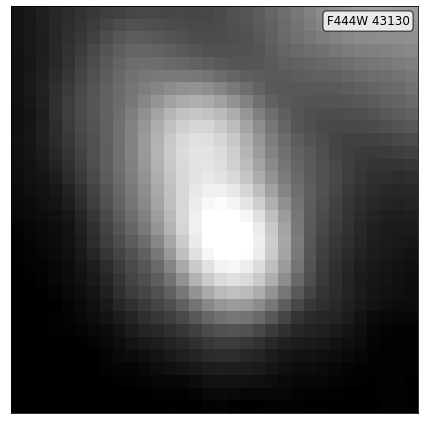

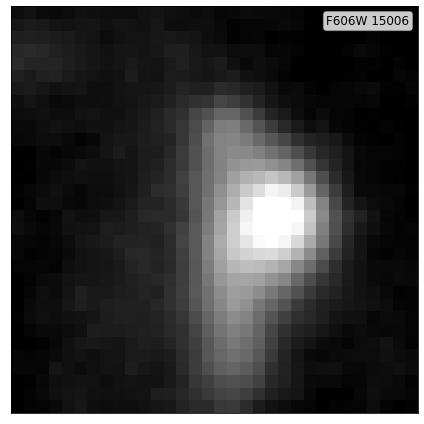

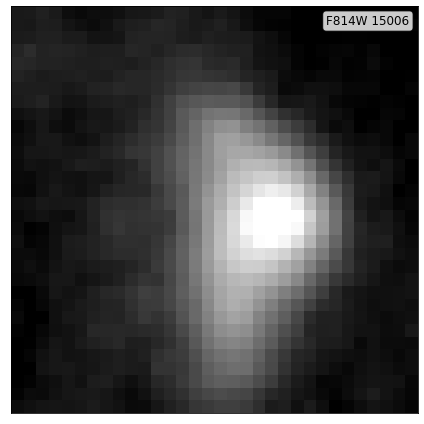

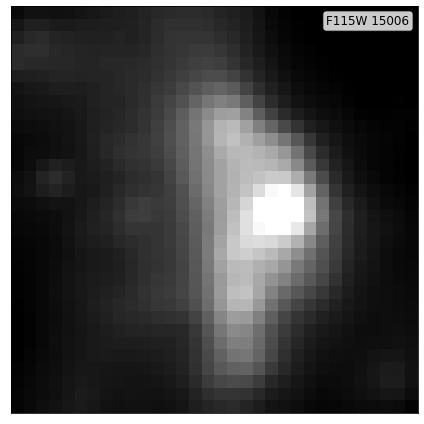

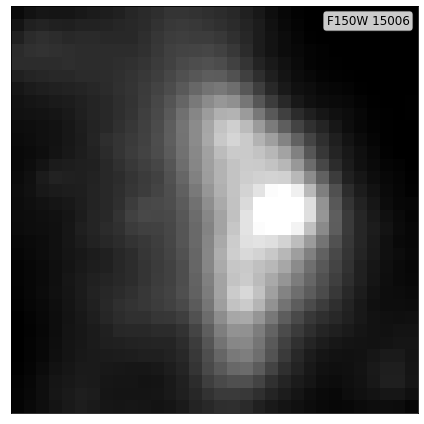

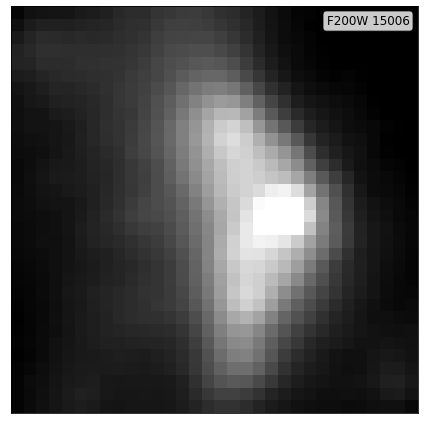

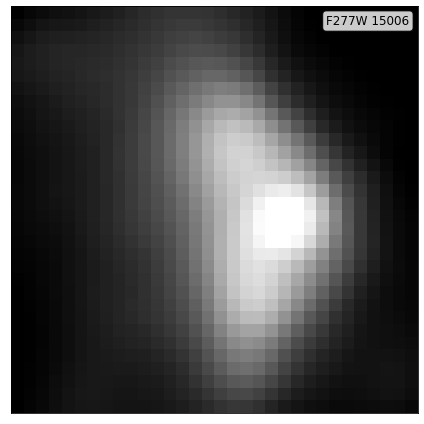

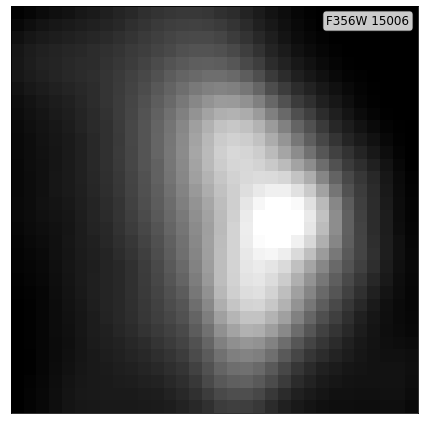

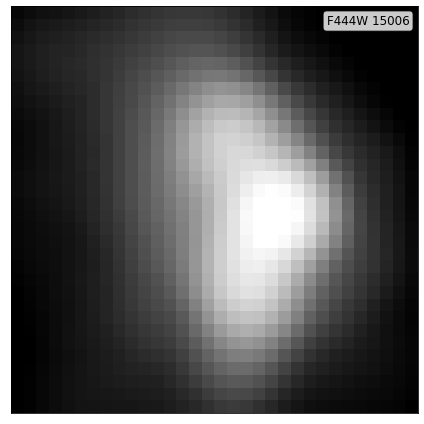

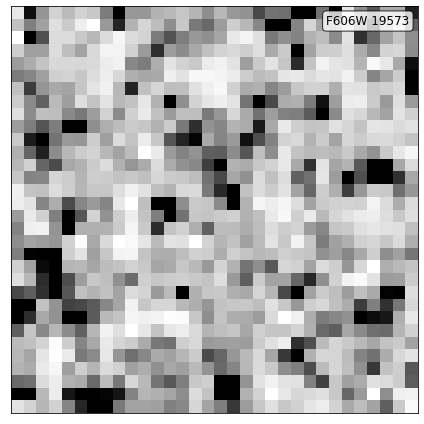

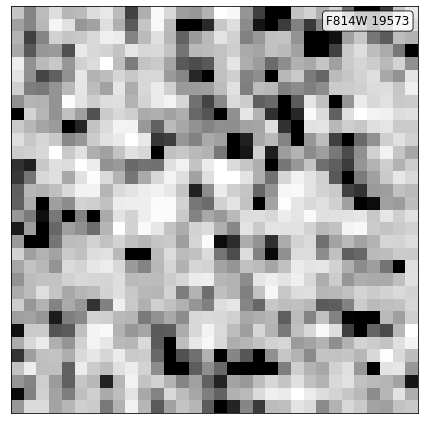

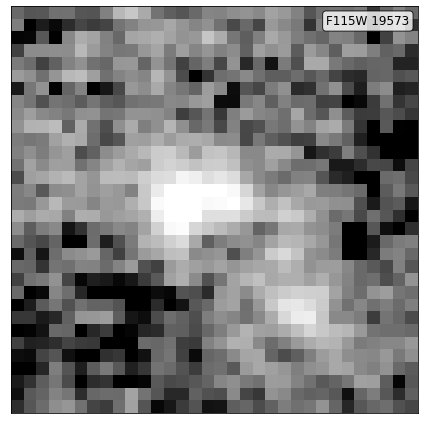

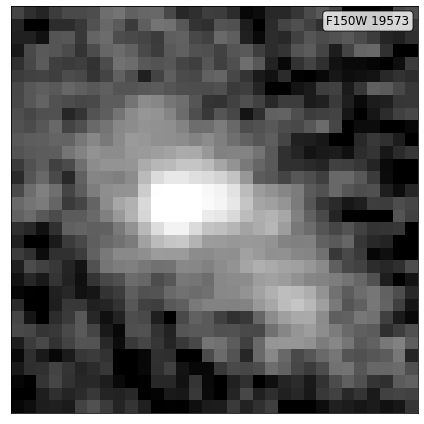

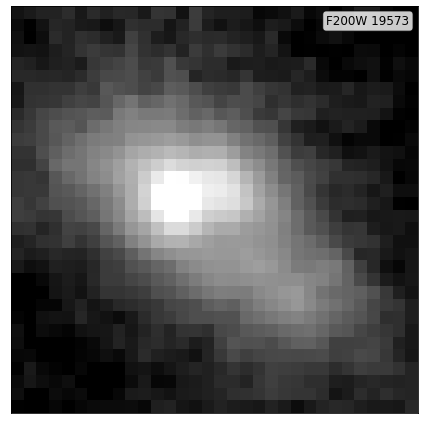

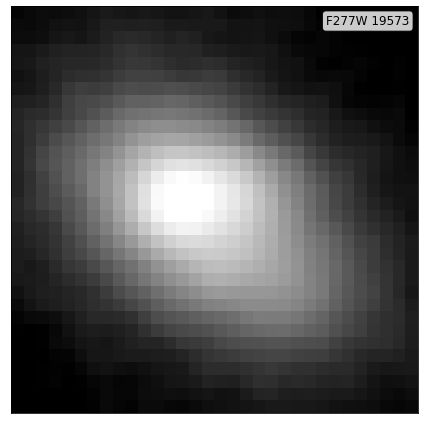

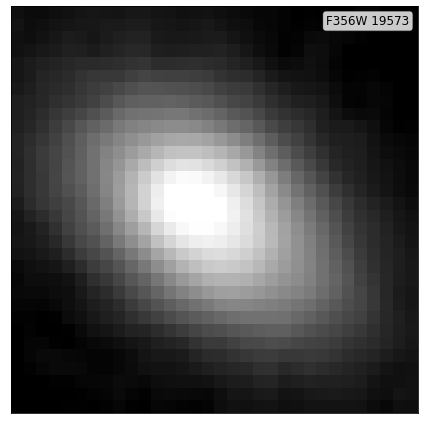

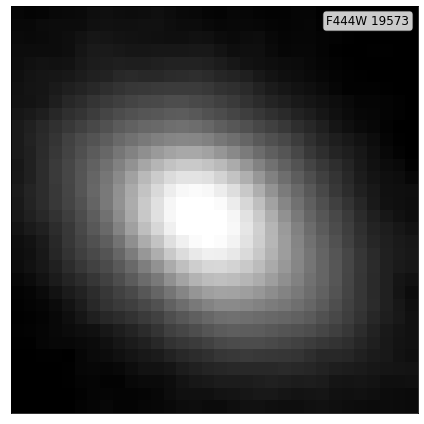

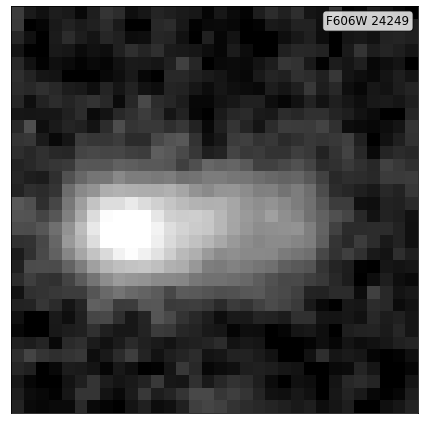

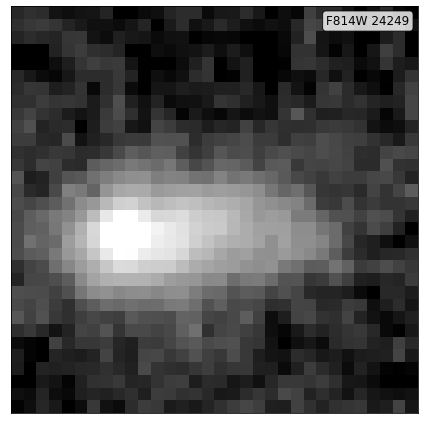

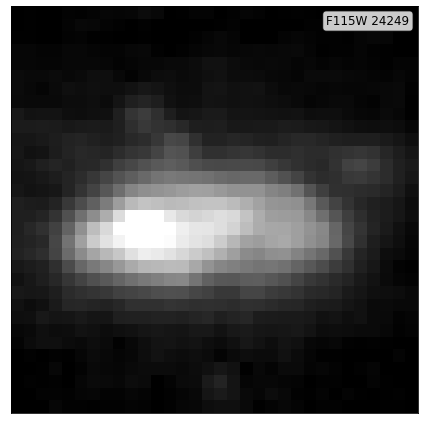

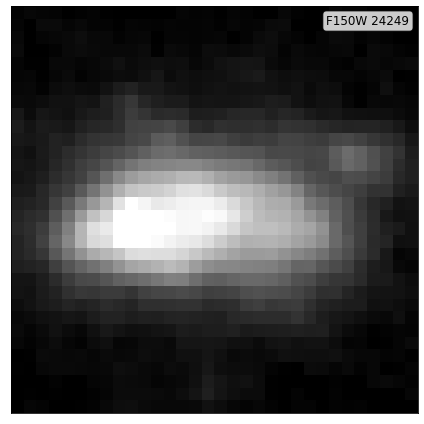

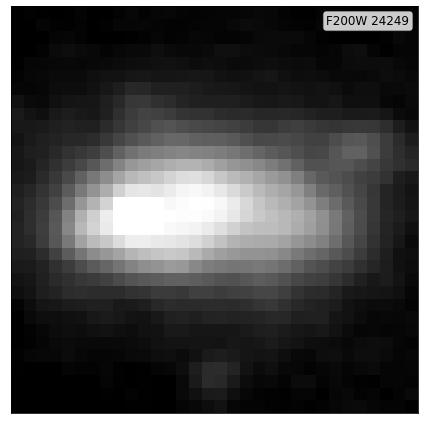

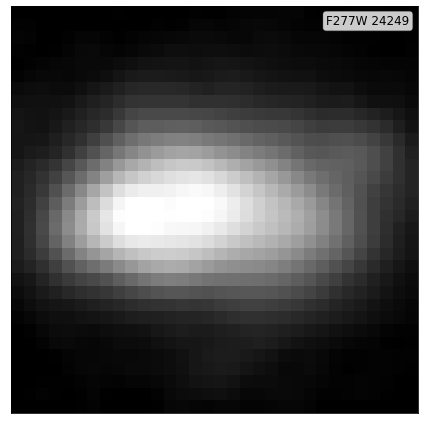

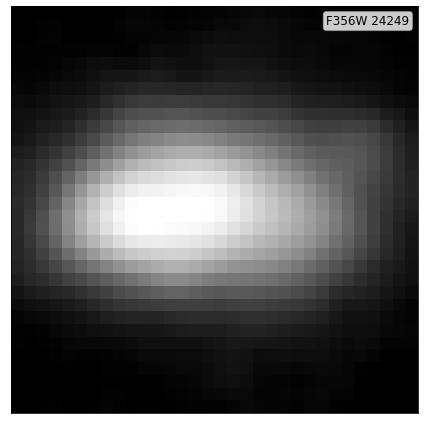

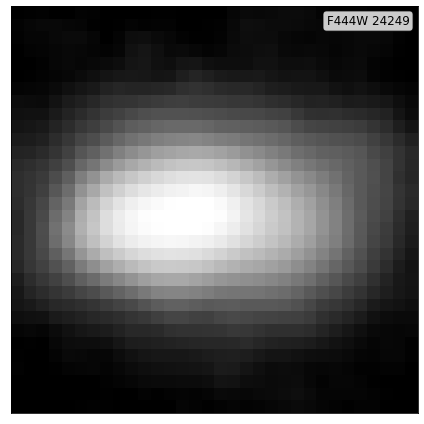

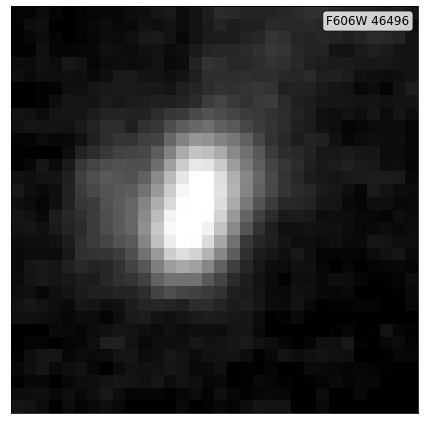

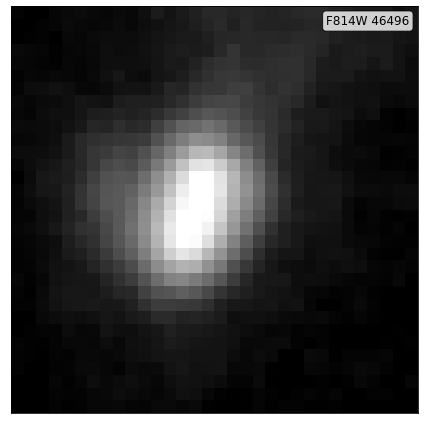

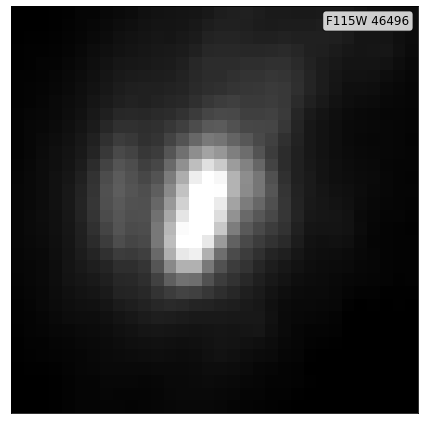

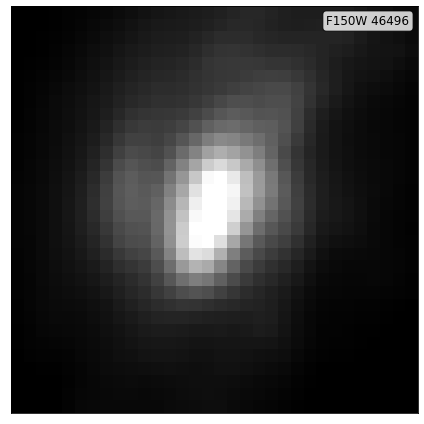

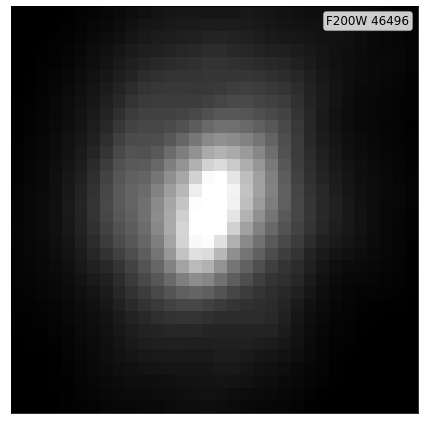

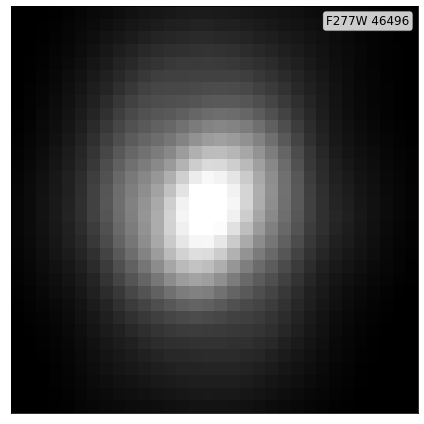

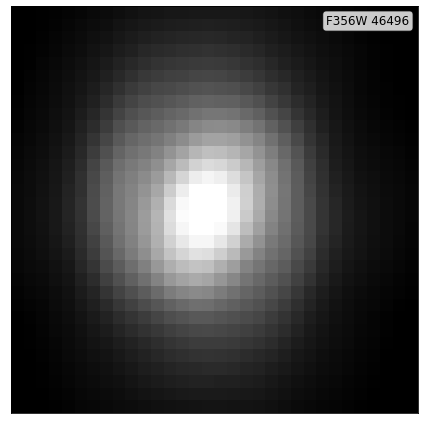

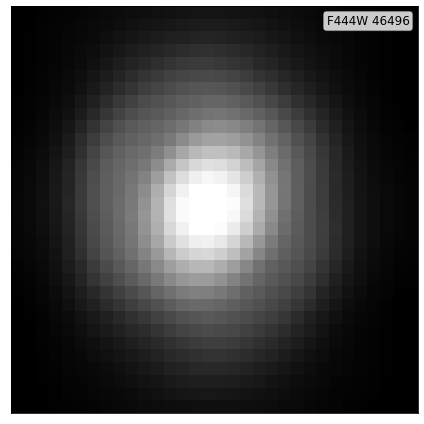

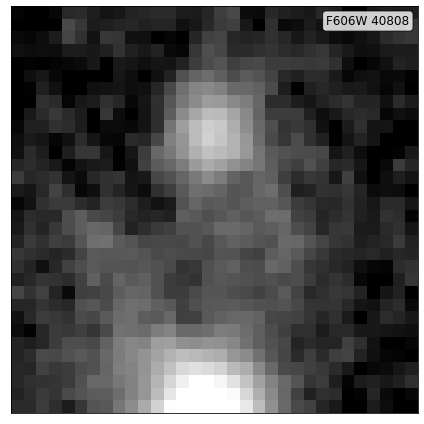

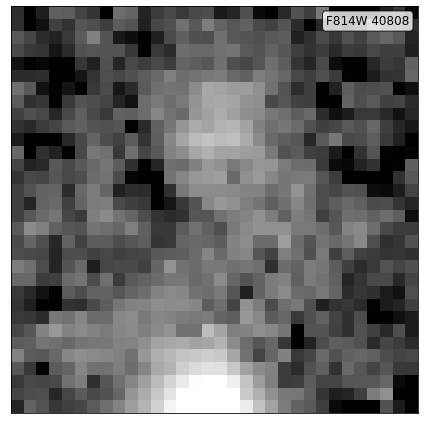

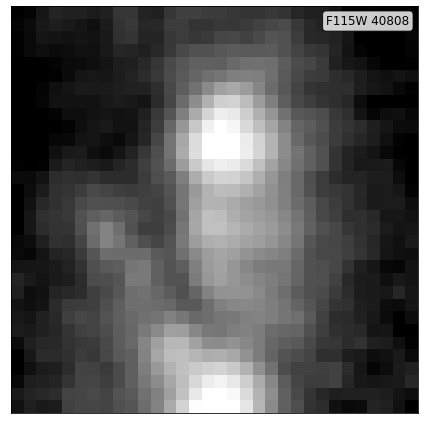

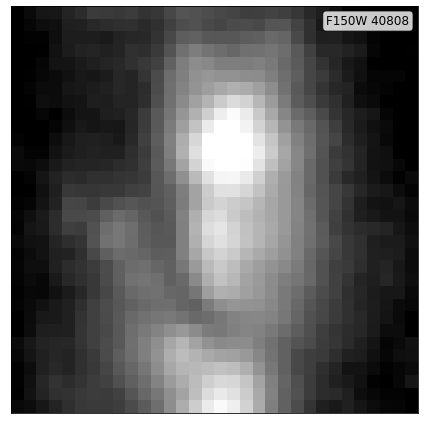

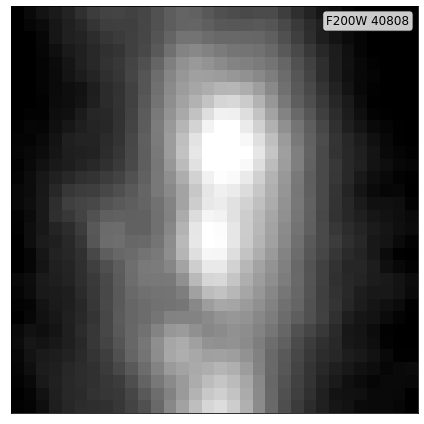

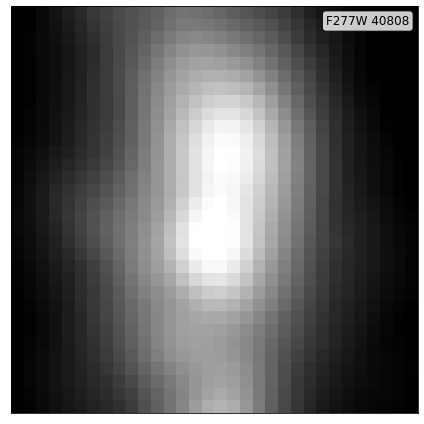

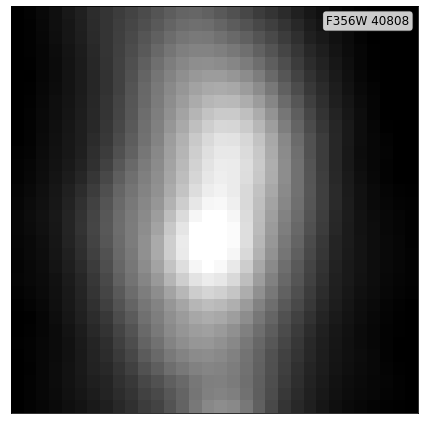

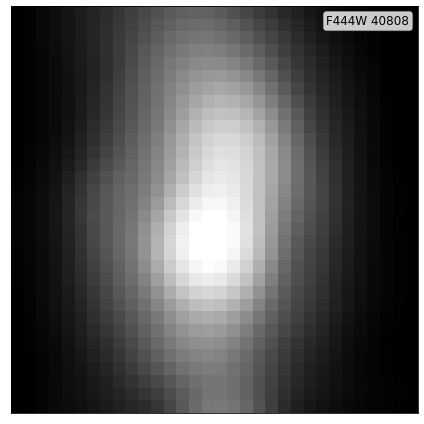

Galaxy 5201 could not be found in these surveys
Galaxy 15034 could not be found in these surveys


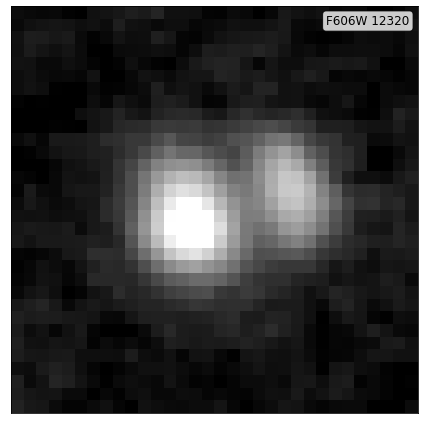

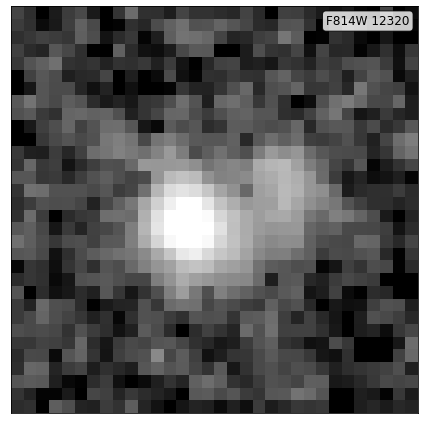

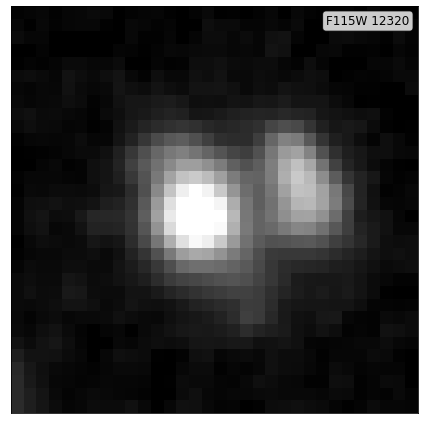

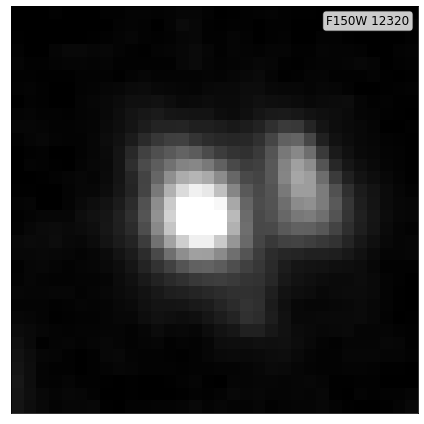

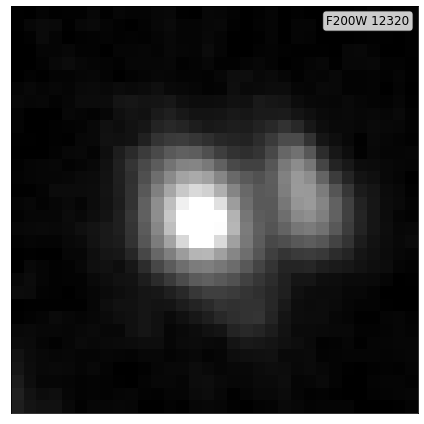

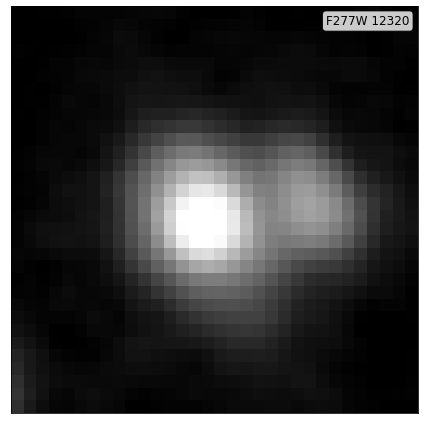

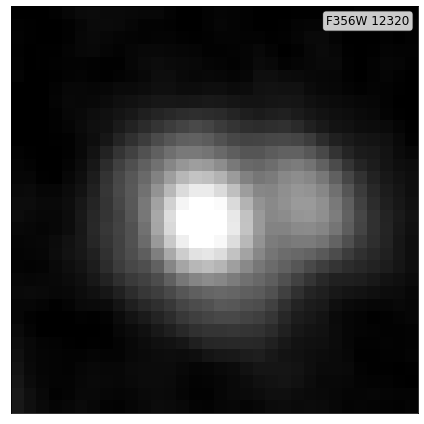

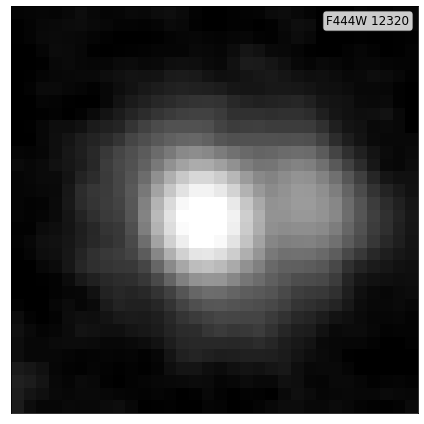

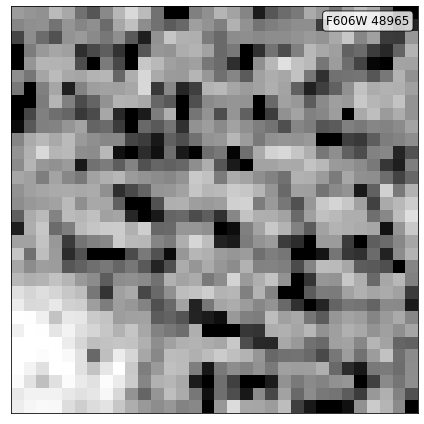

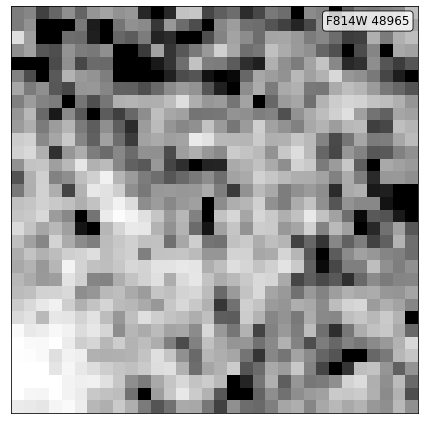

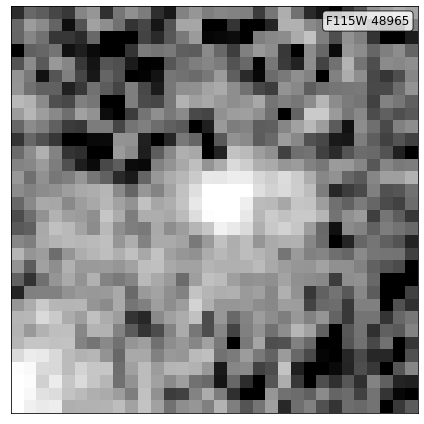

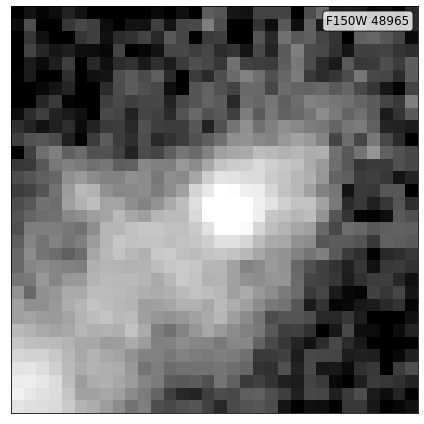

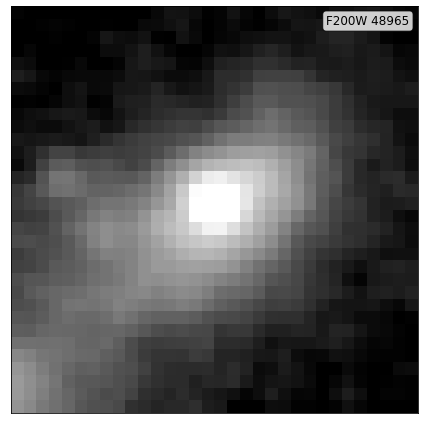

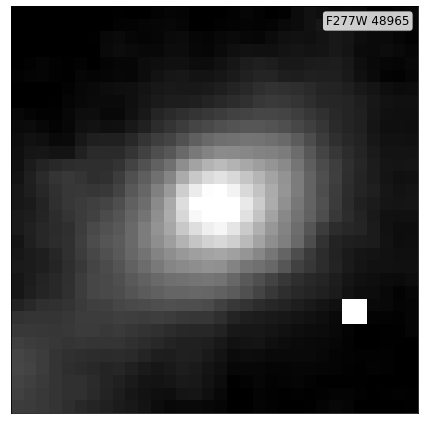

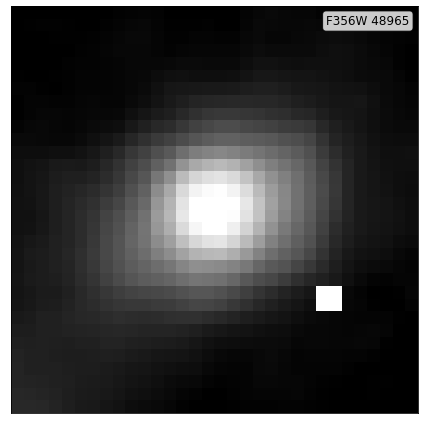

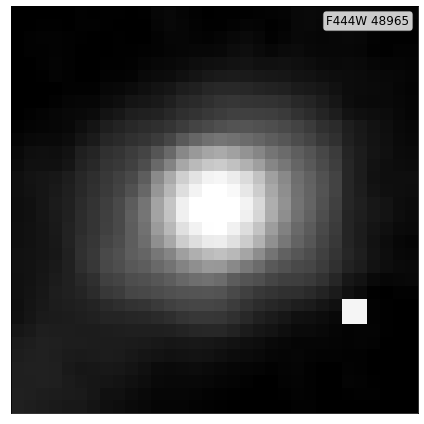

Galaxy 211293 could not be found in these surveys
Galaxy 55521 could not be found in these surveys
Galaxy 239709 could not be found in these surveys


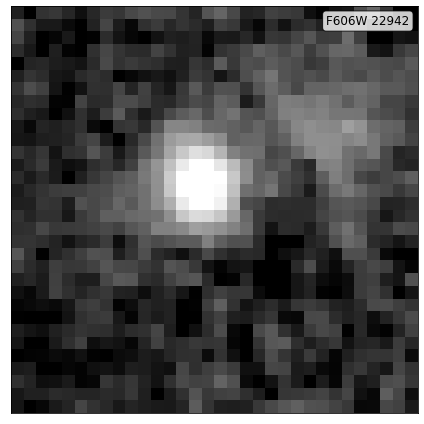

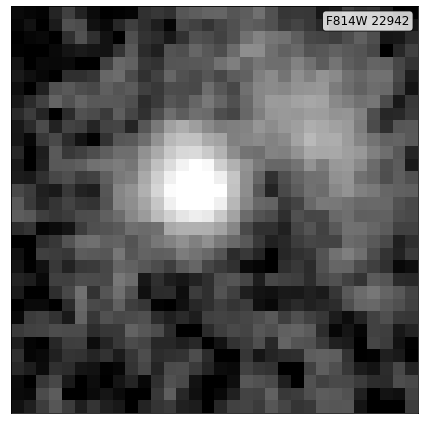

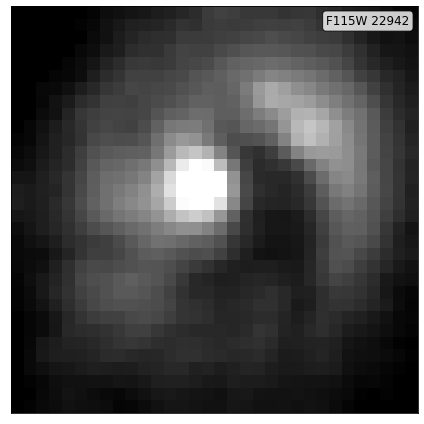

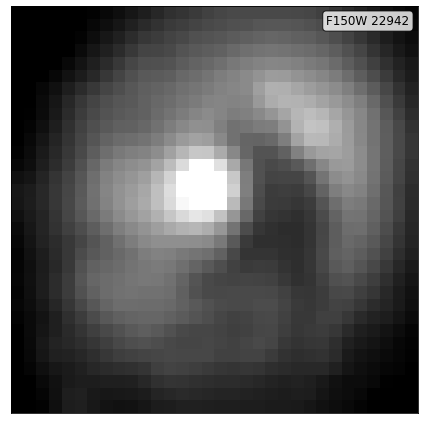

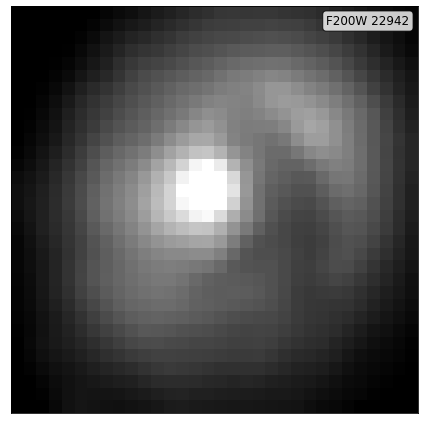

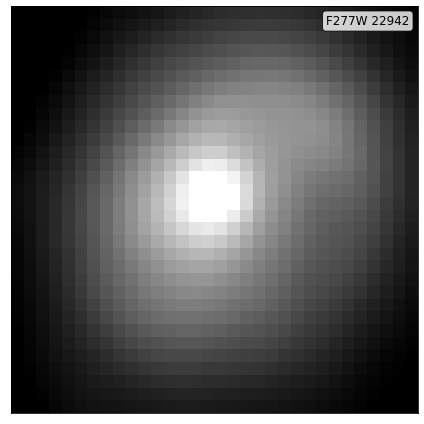

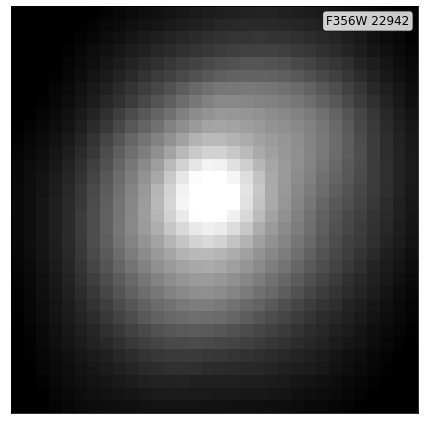

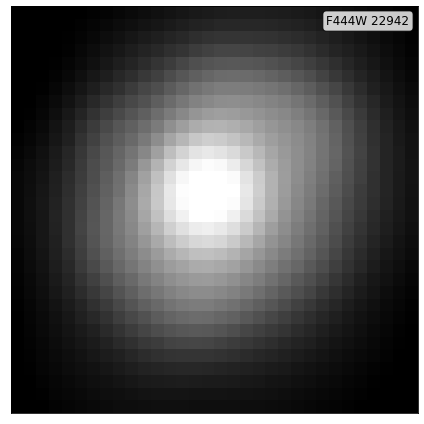

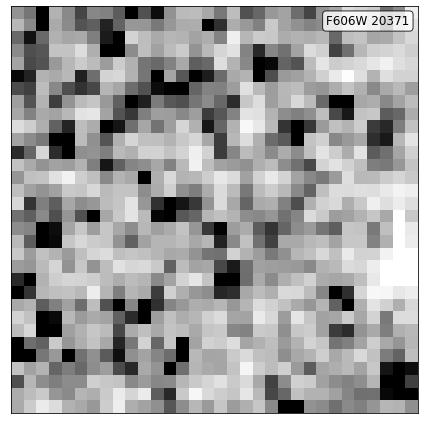

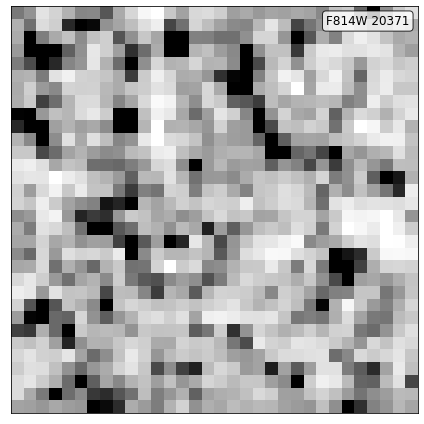

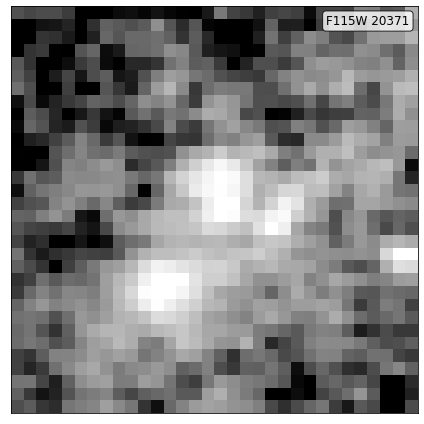

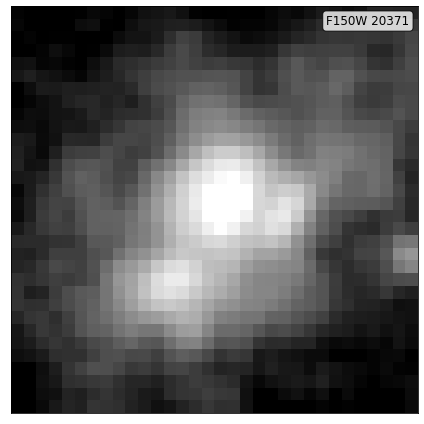

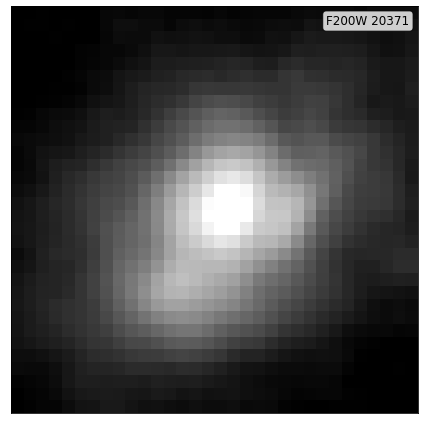

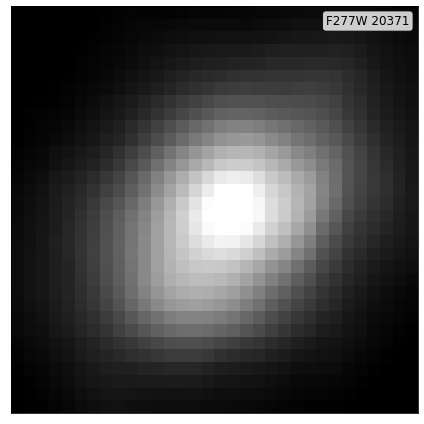

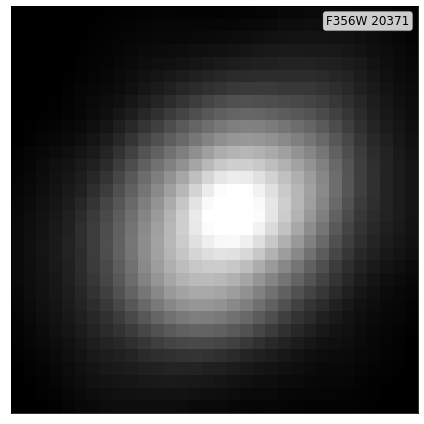

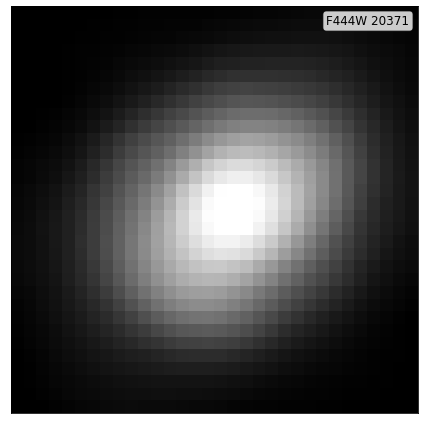

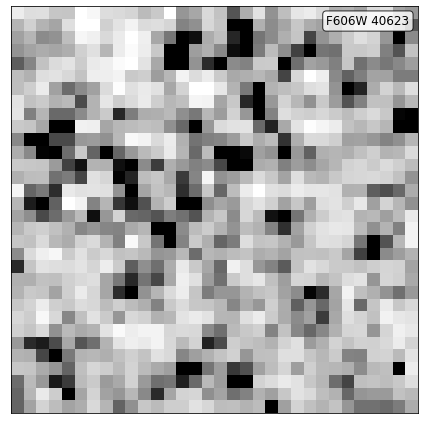

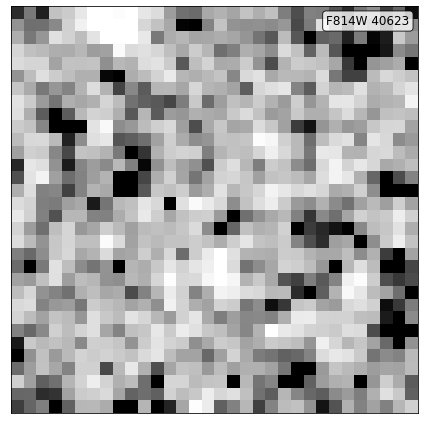

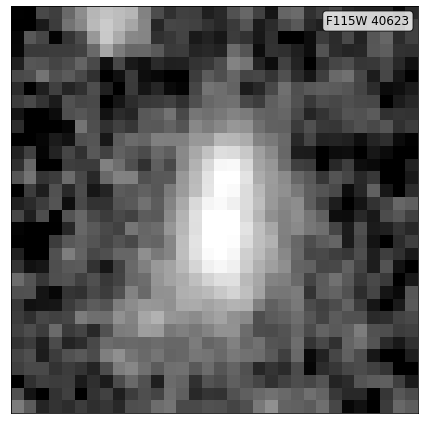

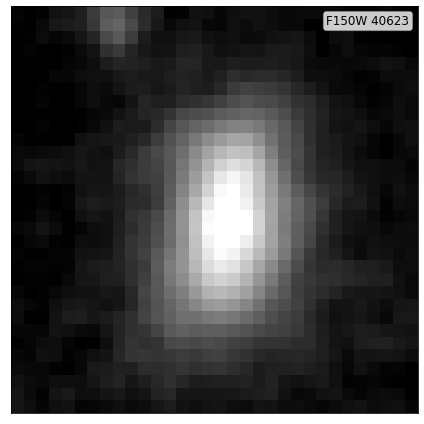

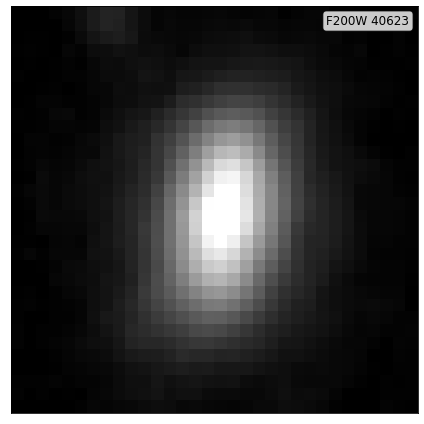

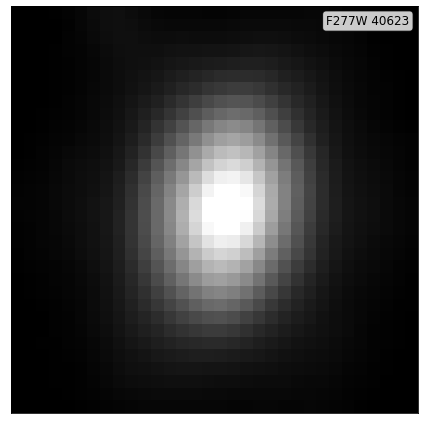

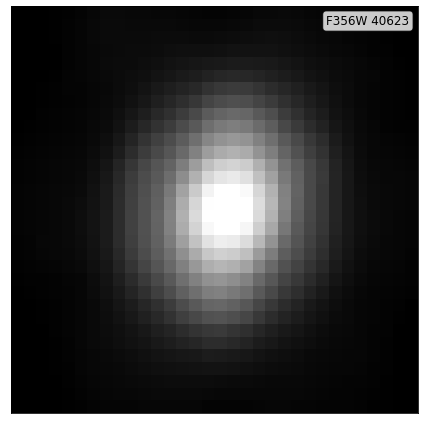

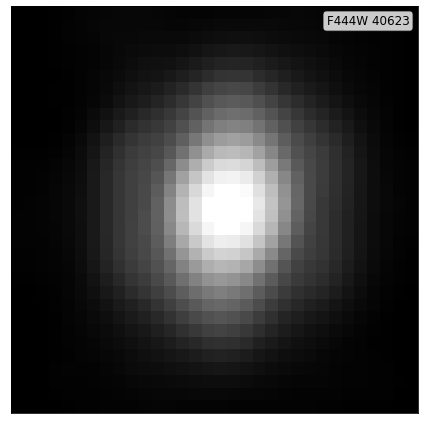

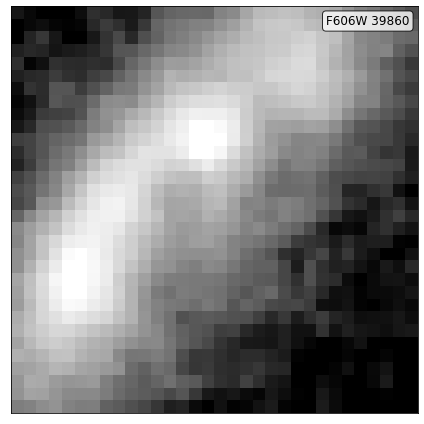

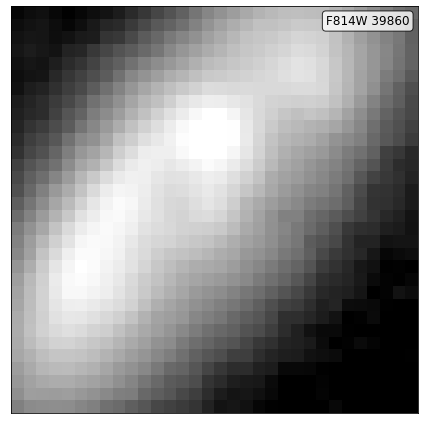

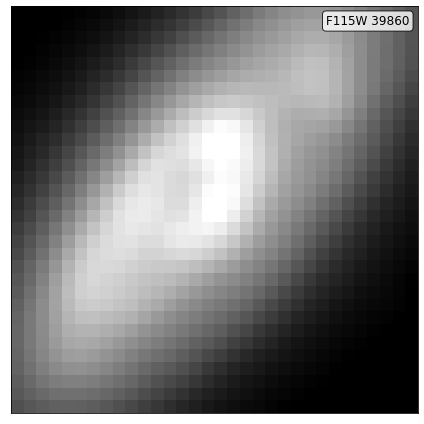

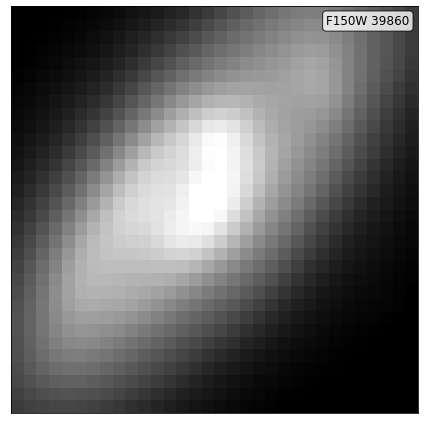

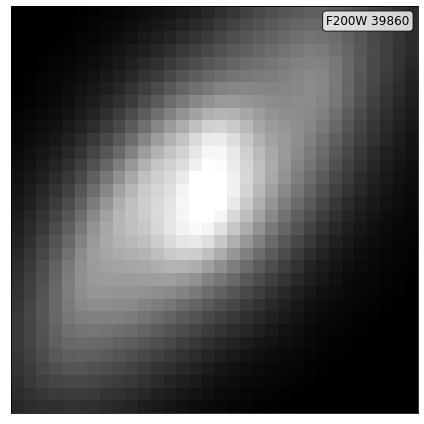

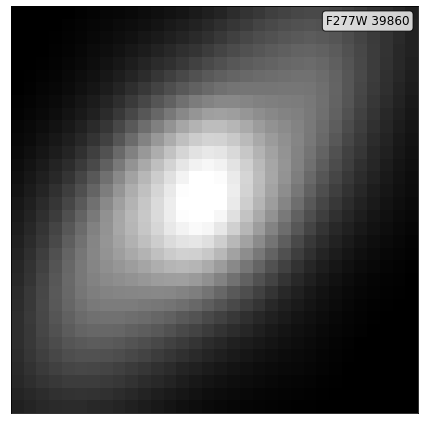

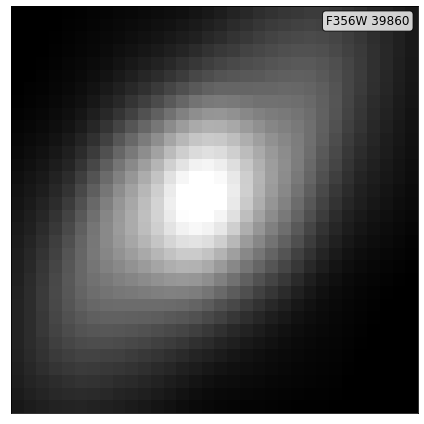

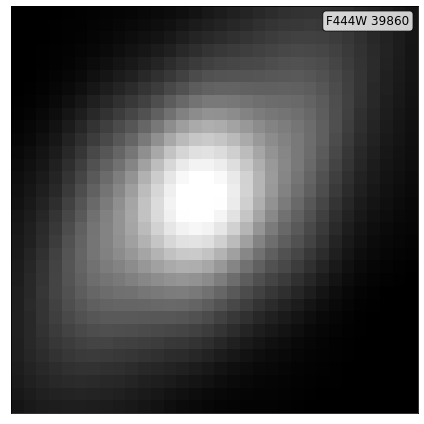

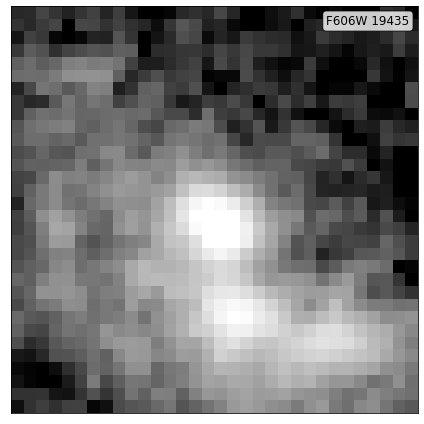

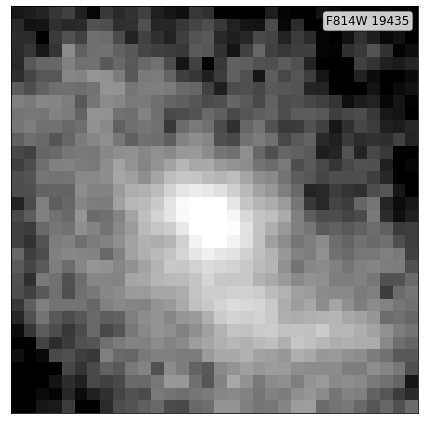

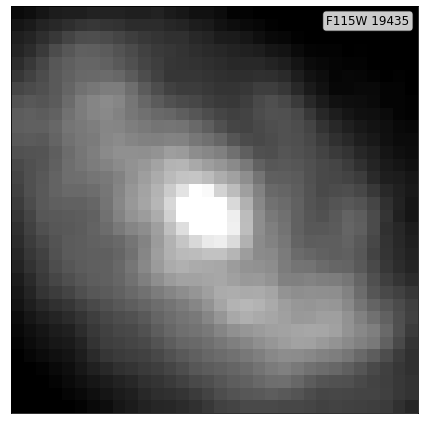

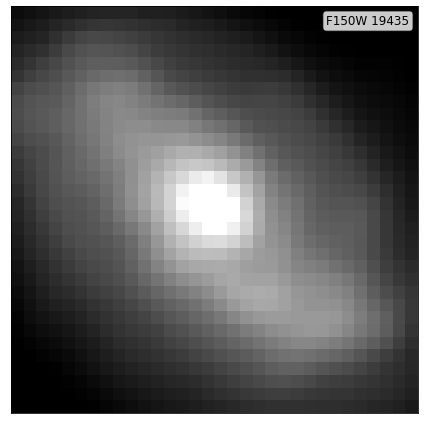

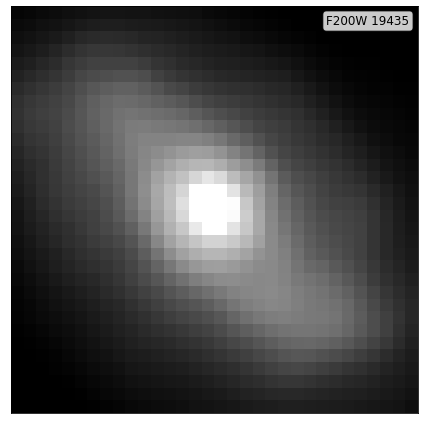

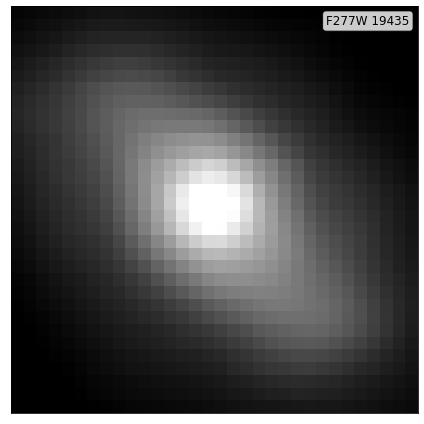

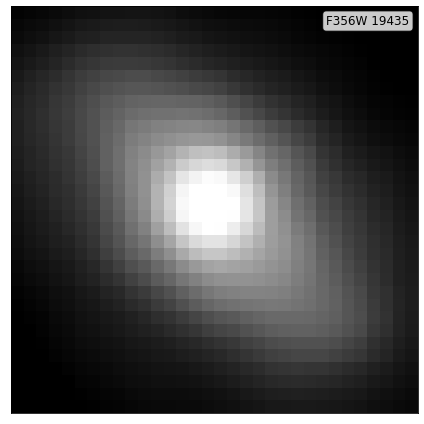

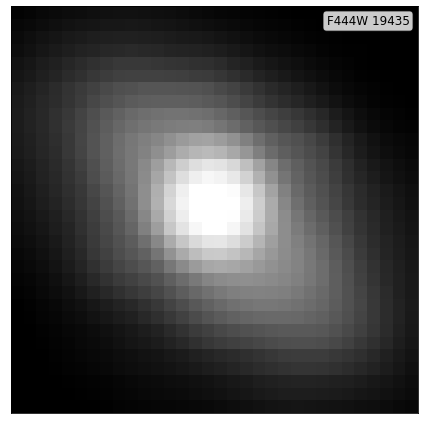

Galaxy 44883 could not be found in these surveys
Galaxy 185028 could not be found in these surveys
Galaxy 52539 could not be found in these surveys
Galaxy 160077 could not be found in these surveys
Galaxy 148827 could not be found in these surveys
Galaxy 76998 could not be found in these surveys


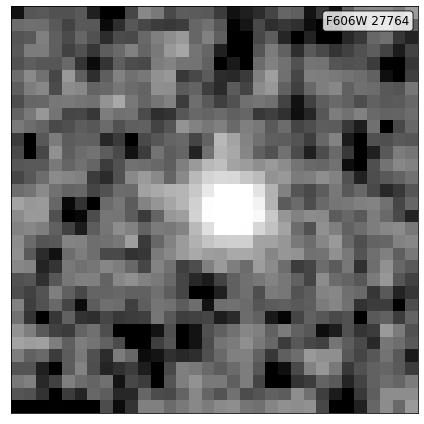

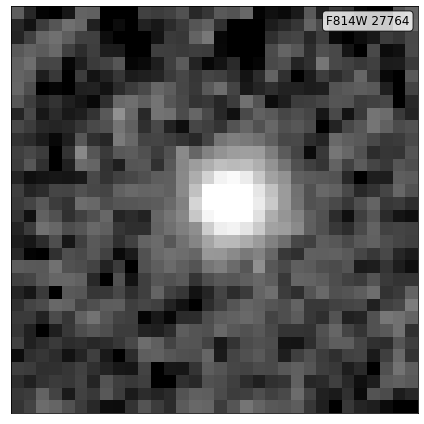

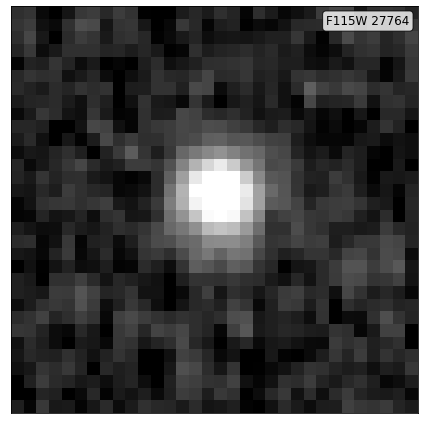

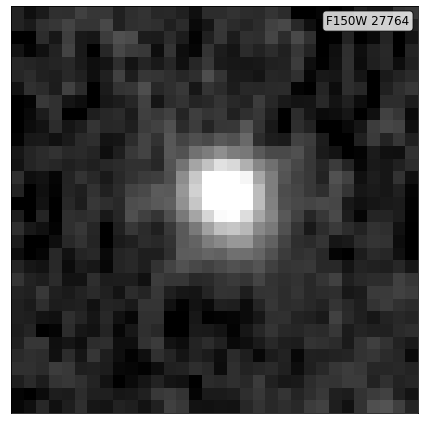

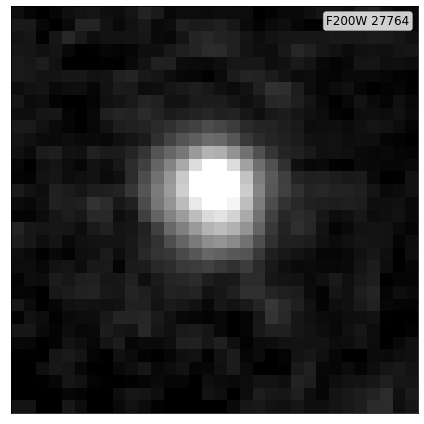

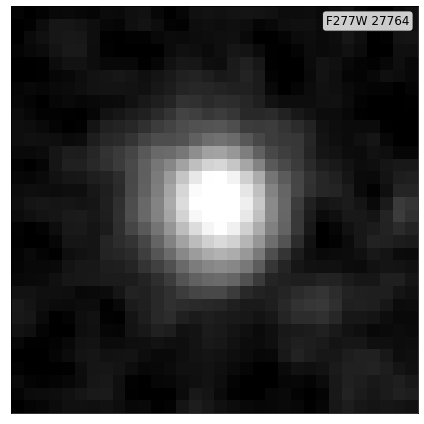

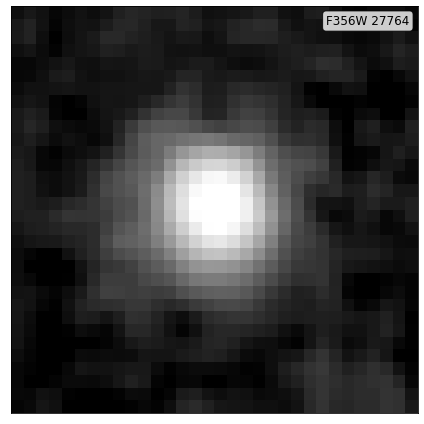

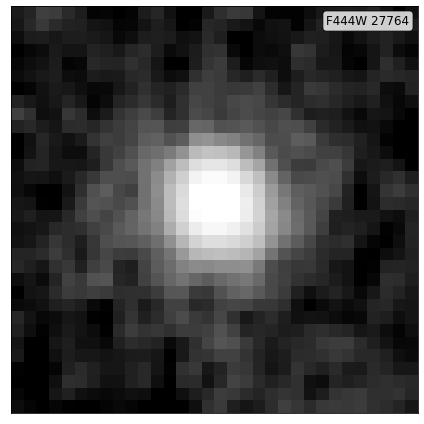

Galaxy 93088 could not be found in these surveys
Galaxy 965 could not be found in these surveys
Galaxy 5318 could not be found in these surveys
Galaxy 2620 could not be found in these surveys
Galaxy 6964 could not be found in these surveys
Galaxy 6576 could not be found in these surveys
Galaxy 9801 could not be found in these surveys
Galaxy 4234 could not be found in these surveys
Galaxy 140605 could not be found in these surveys
Galaxy 130533 could not be found in these surveys
Galaxy 3405 could not be found in these surveys


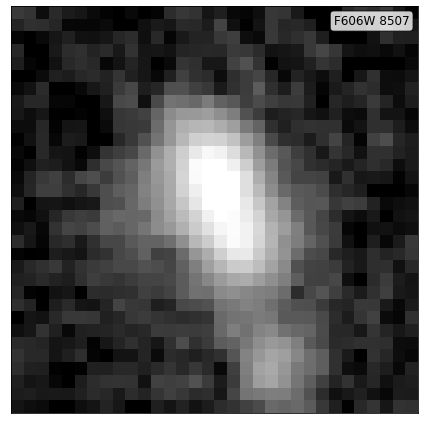

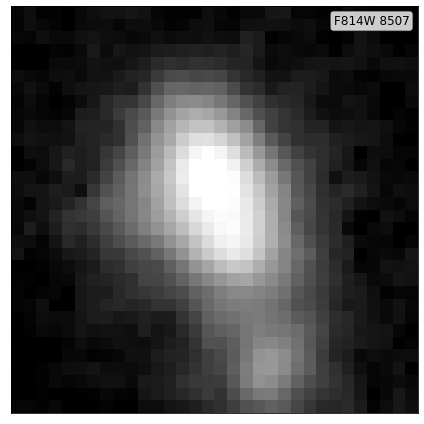

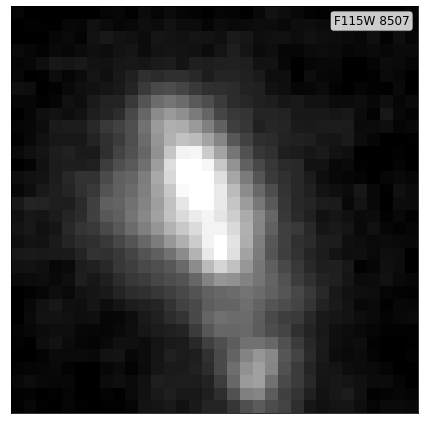

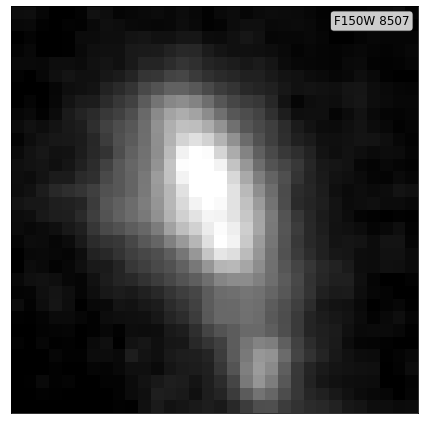

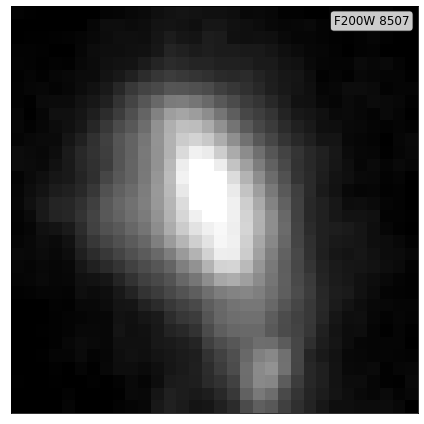

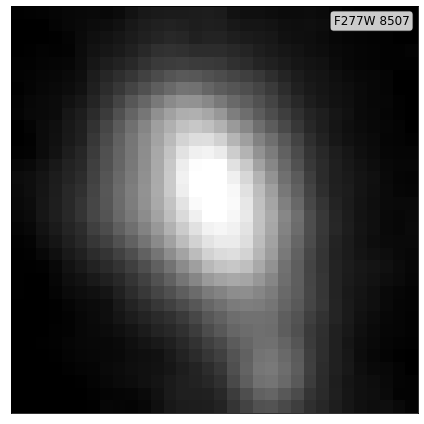

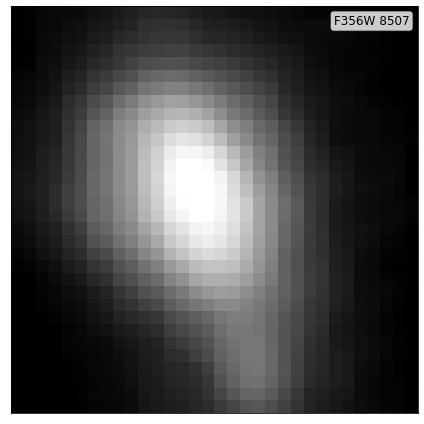

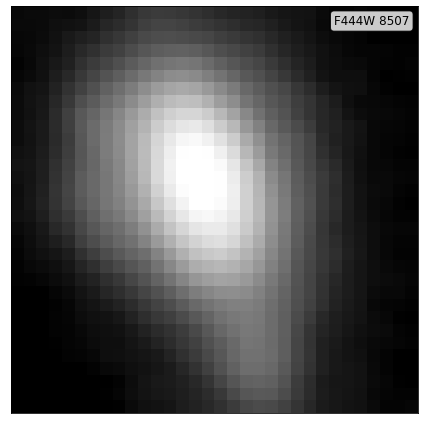

Galaxy 11701 could not be found in these surveys
Galaxy 27685 could not be found in these surveys
Galaxy 78529 could not be found in these surveys
Galaxy 146132 could not be found in these surveys
Galaxy 159133 could not be found in these surveys
Galaxy 8112 could not be found in these surveys
Galaxy 134028 could not be found in these surveys
Galaxy 54465 could not be found in these surveys
Galaxy 59715 could not be found in these surveys
Galaxy 61115 could not be found in these surveys
Galaxy 61573 could not be found in these surveys
Galaxy 72482 could not be found in these surveys
Galaxy 73098 could not be found in these surveys
Galaxy 87115 could not be found in these surveys
Galaxy 86751 could not be found in these surveys
Galaxy 86583 could not be found in these surveys
Galaxy 98300 could not be found in these surveys
Galaxy 9766 could not be found in these surveys
Galaxy 9246 could not be found in these surveys
Galaxy 2803 could not be found in these surveys
Galaxy 10835 could no

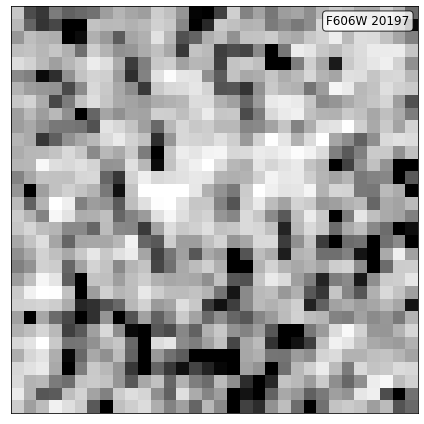

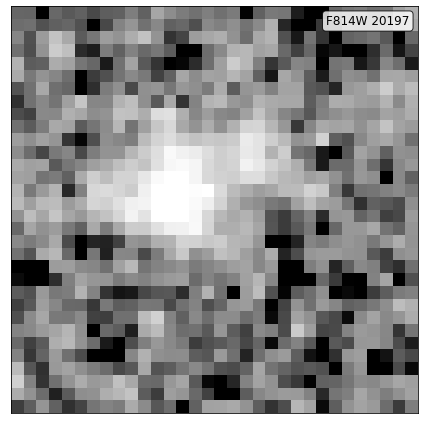

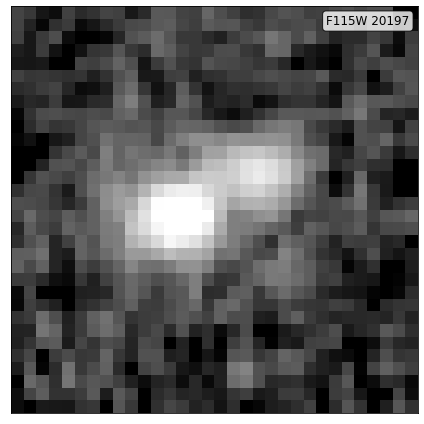

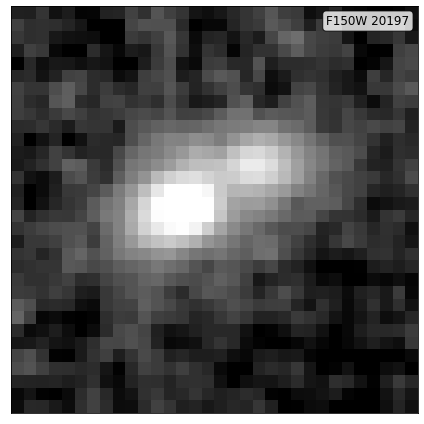

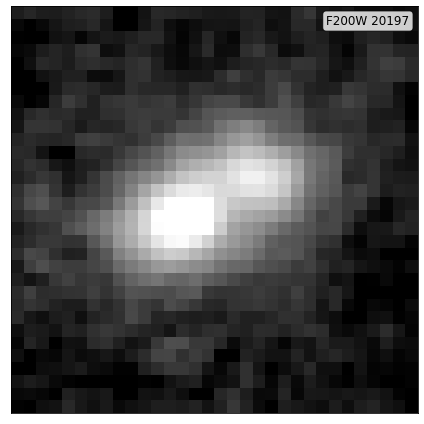

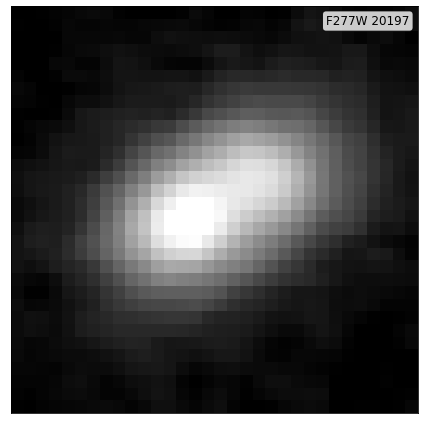

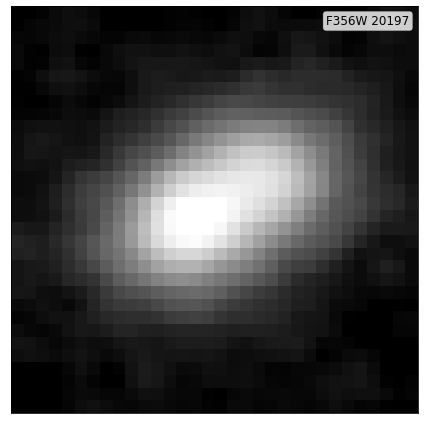

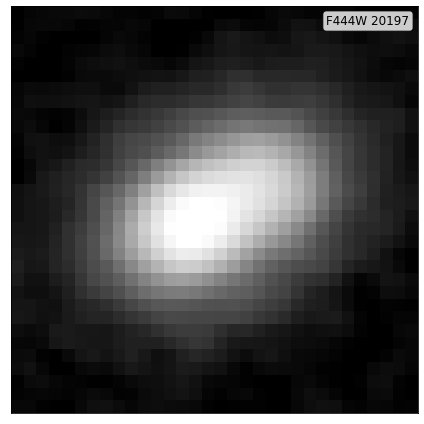

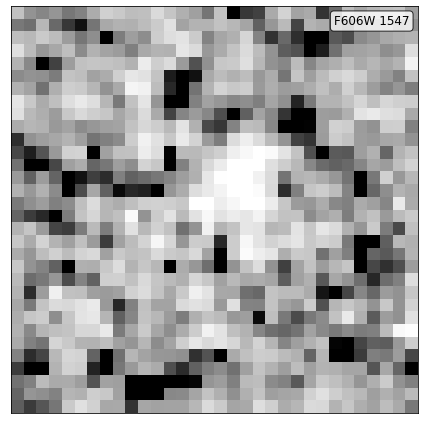

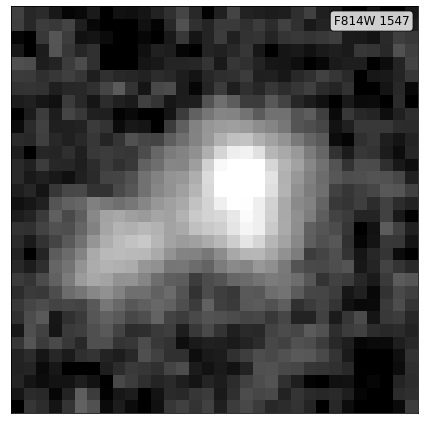

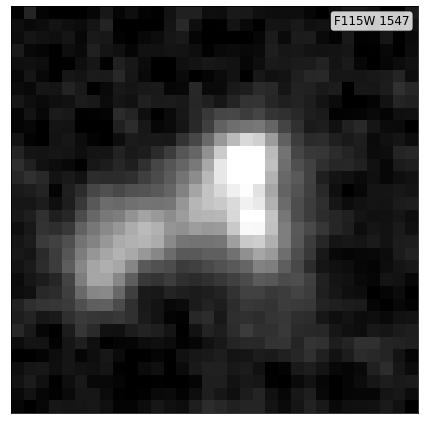

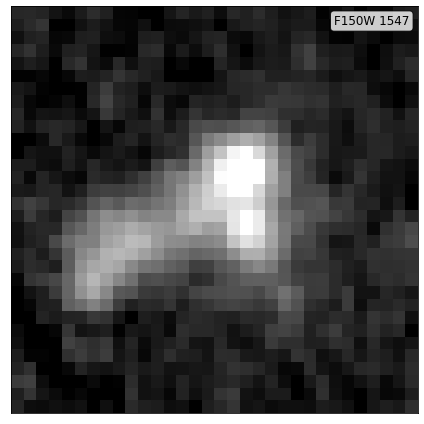

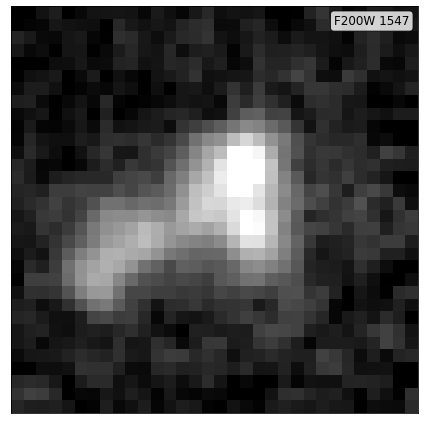

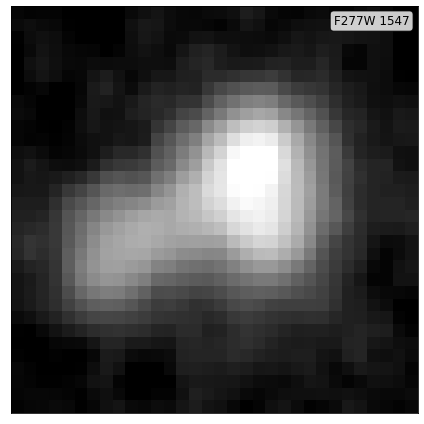

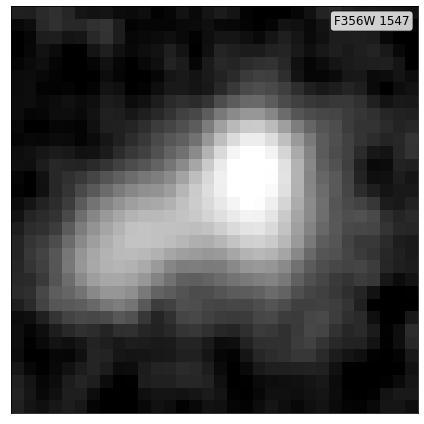

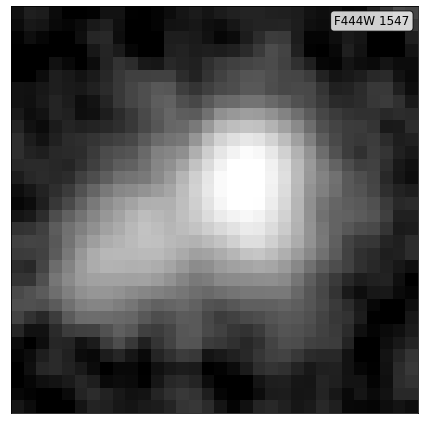

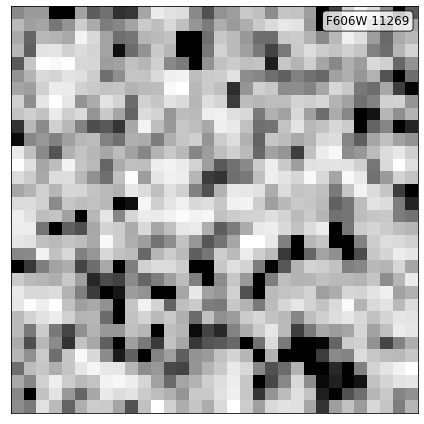

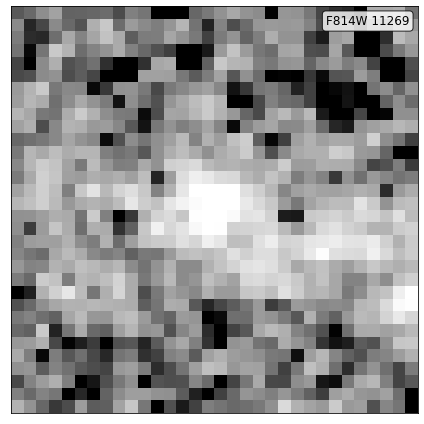

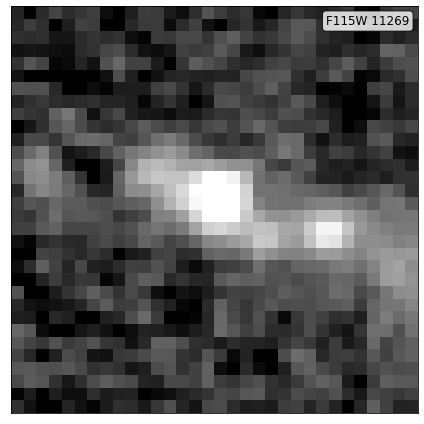

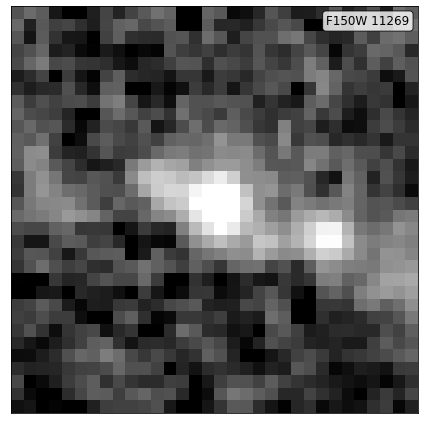

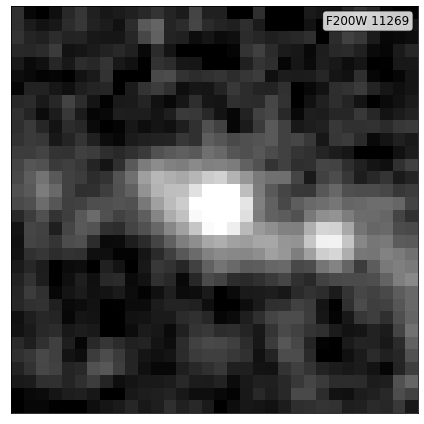

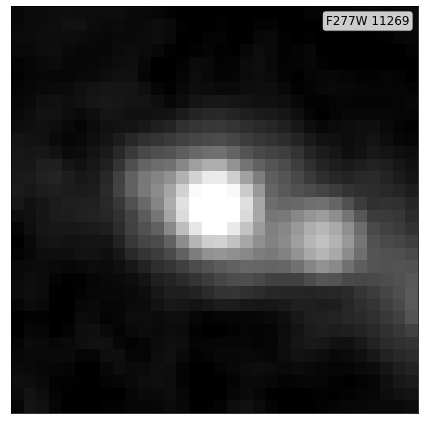

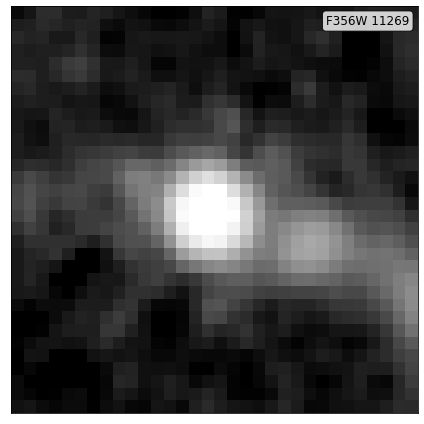

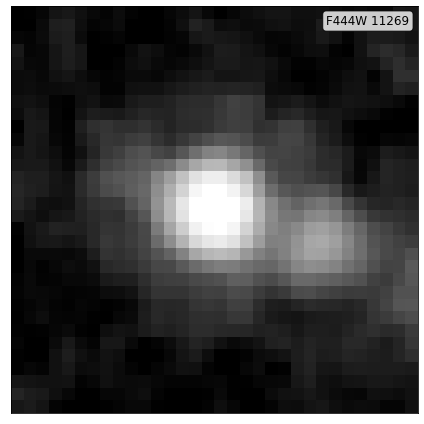

Galaxy 16900 could not be found in these surveys
Galaxy 4119 could not be found in these surveys
Galaxy 5357 could not be found in these surveys
Galaxy 6944 could not be found in these surveys
Galaxy 3514 could not be found in these surveys
Galaxy 6171 could not be found in these surveys
Galaxy 11723 could not be found in these surveys
Galaxy 3723 could not be found in these surveys


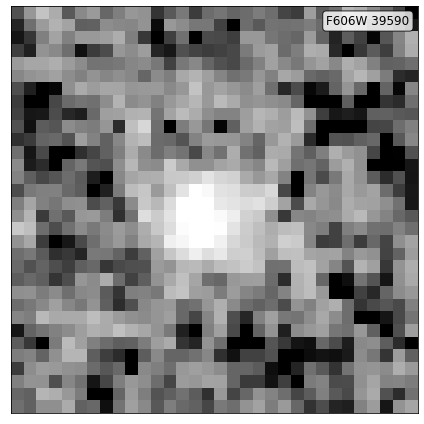

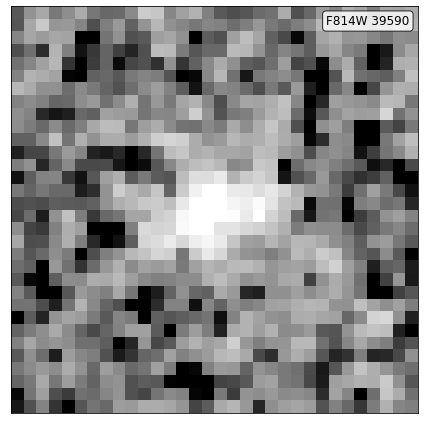

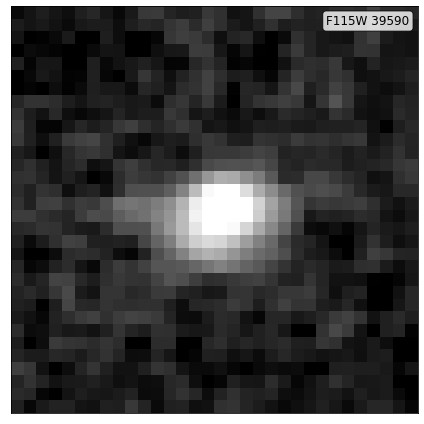

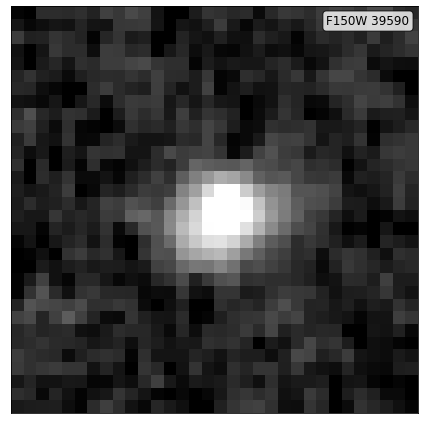

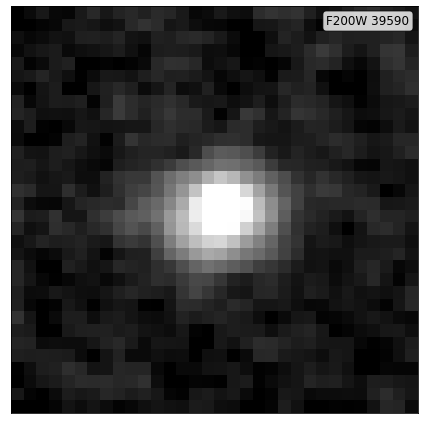

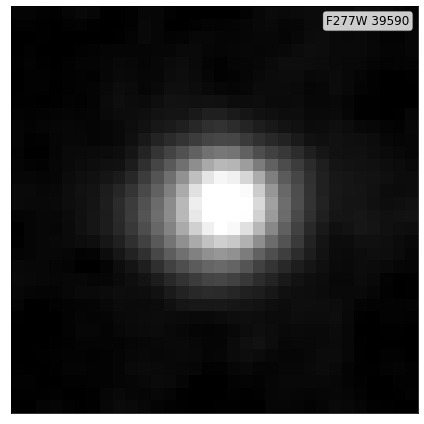

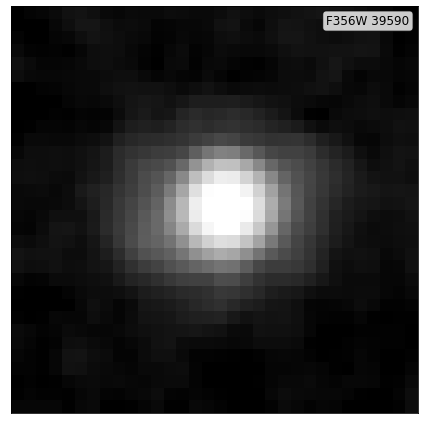

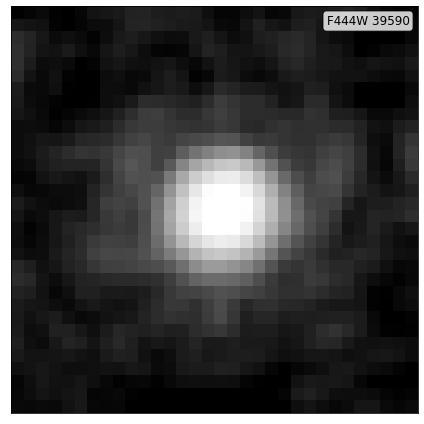

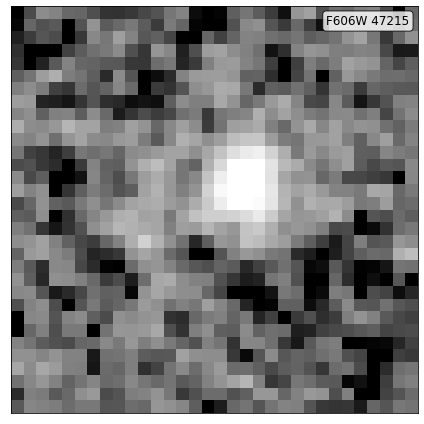

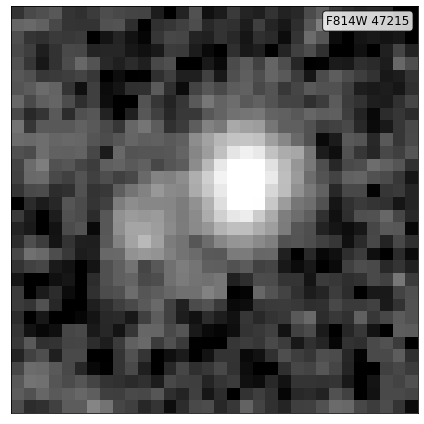

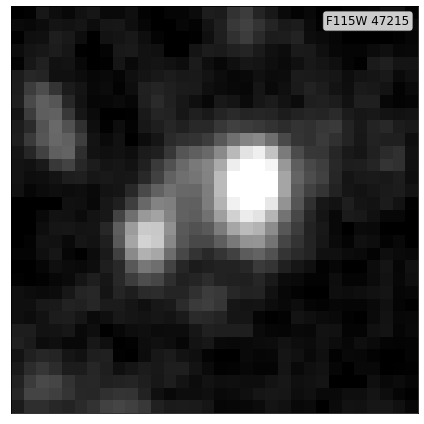

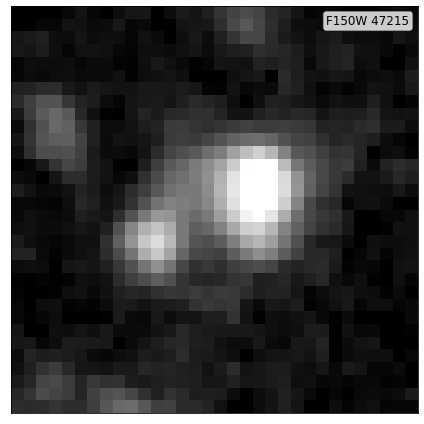

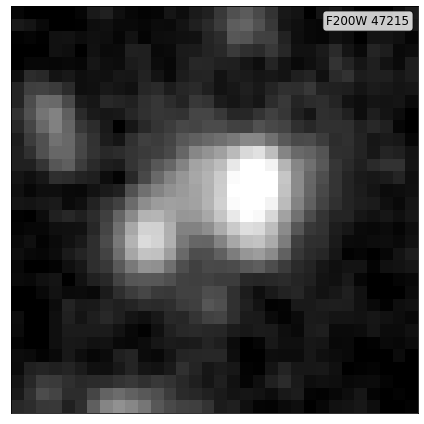

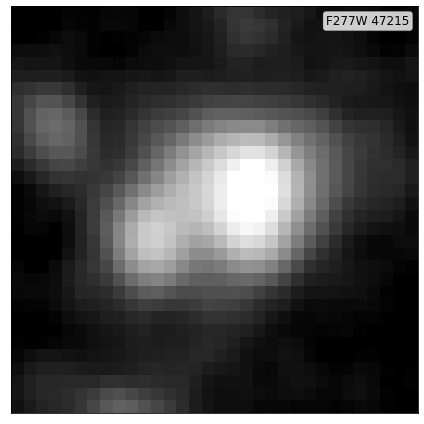

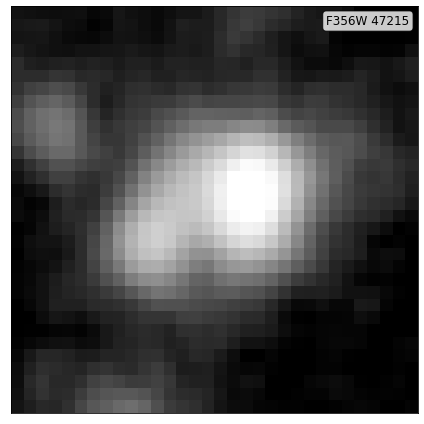

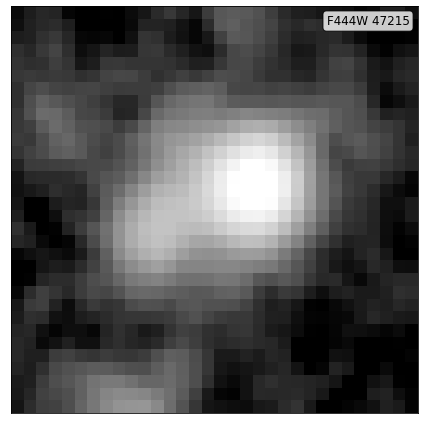

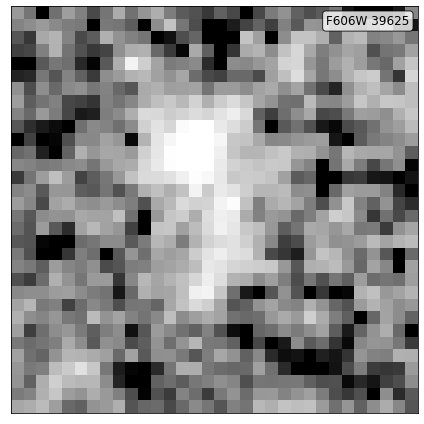

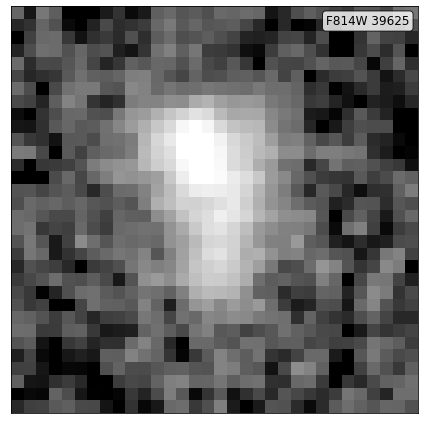

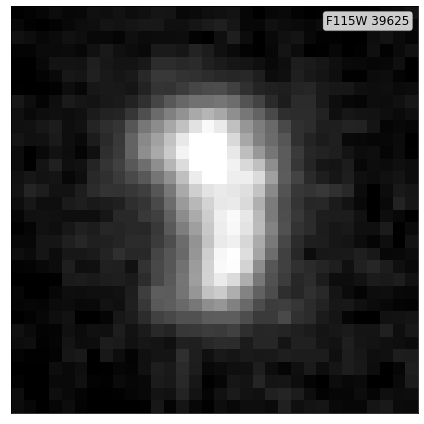

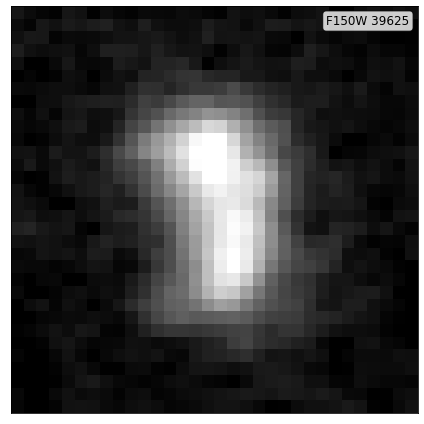

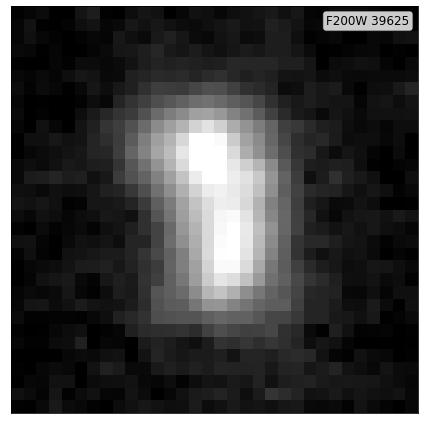

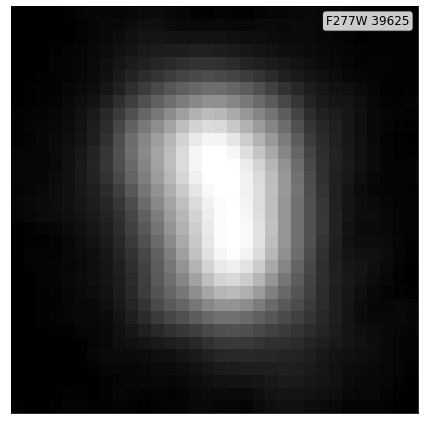

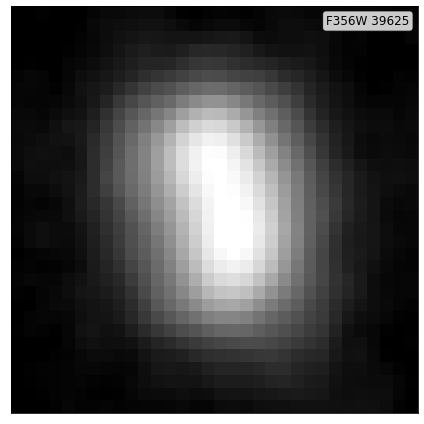

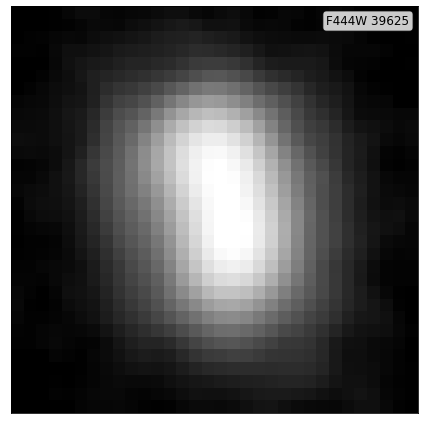

Galaxy 6730 could not be found in these surveys


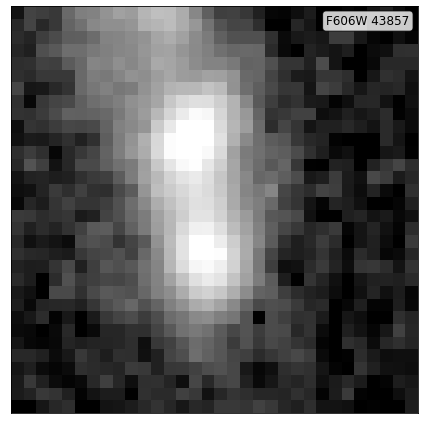

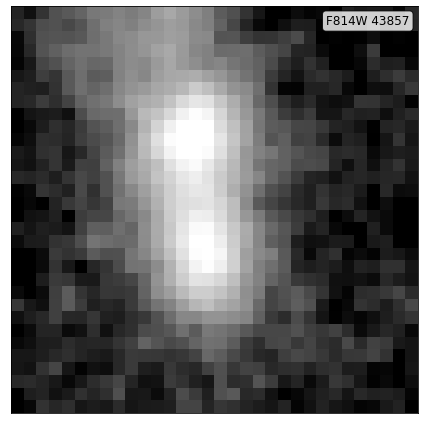

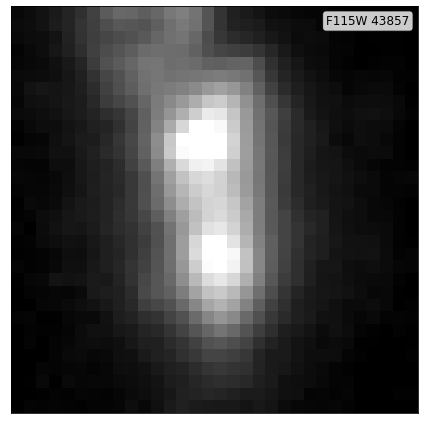

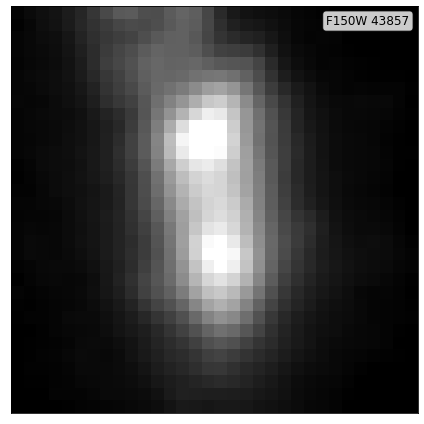

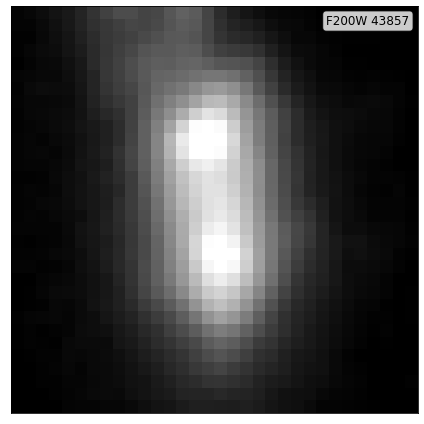

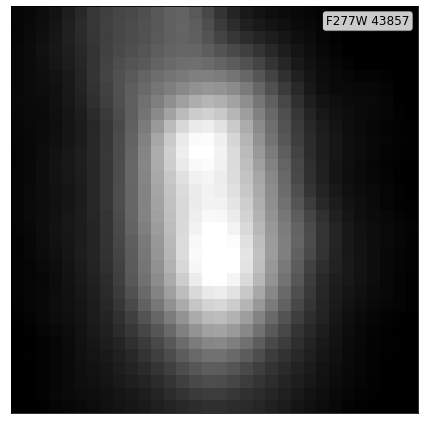

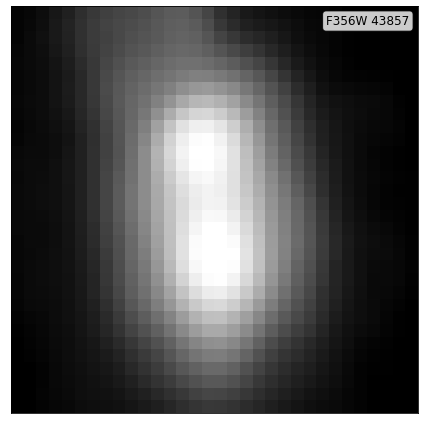

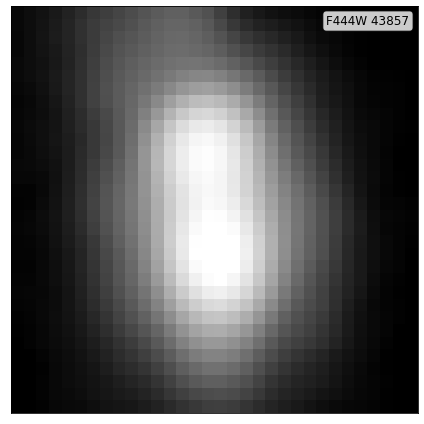

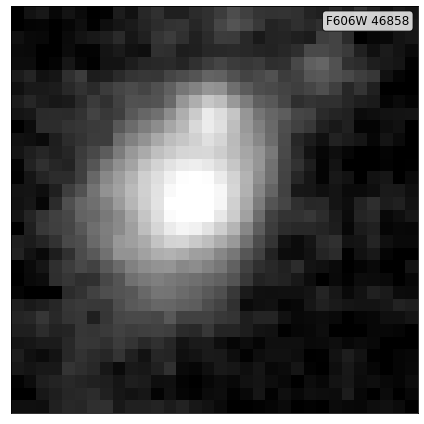

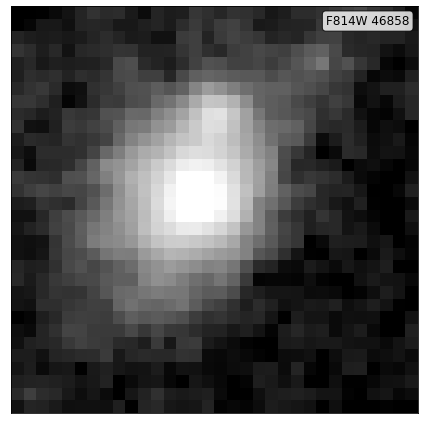

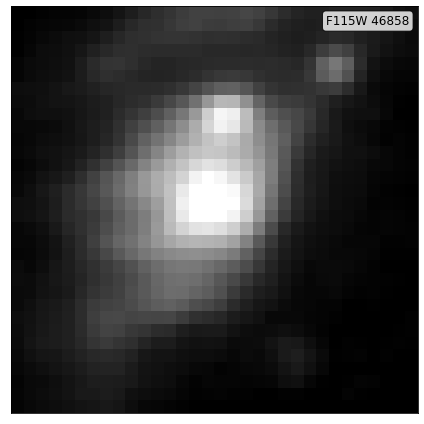

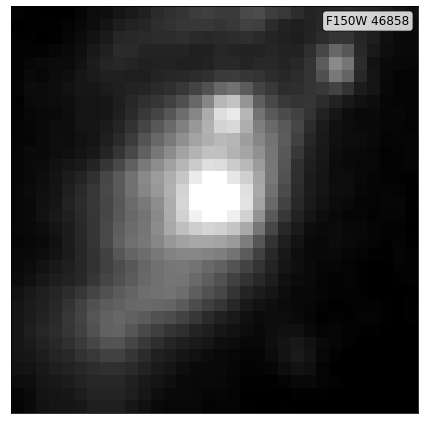

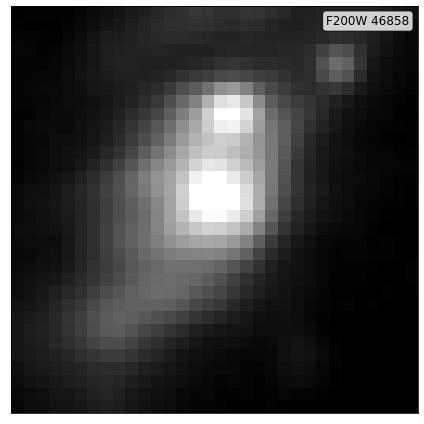

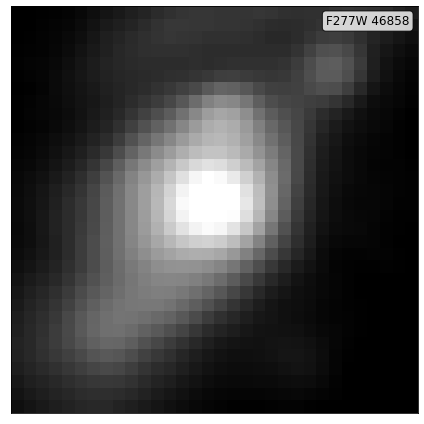

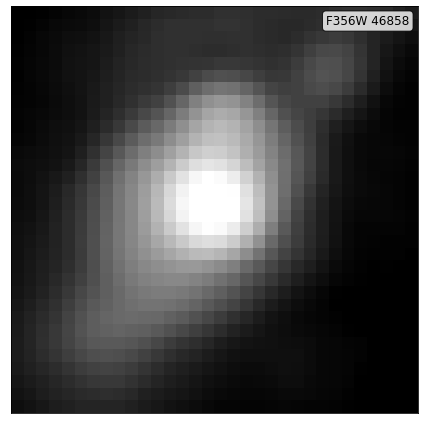

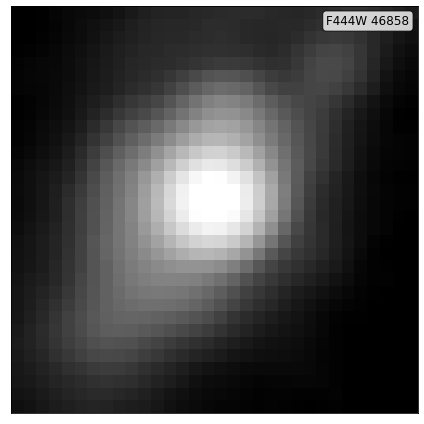

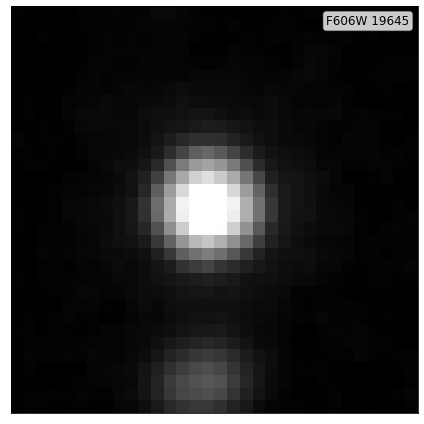

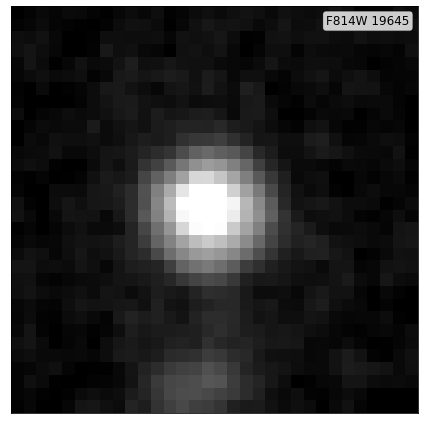

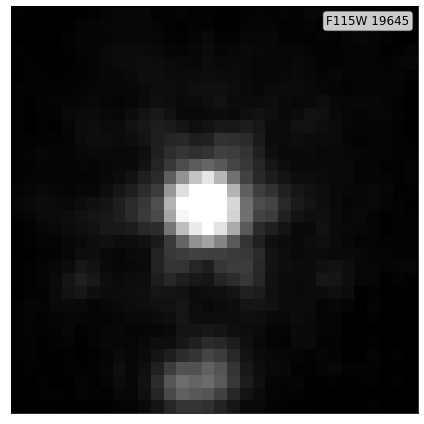

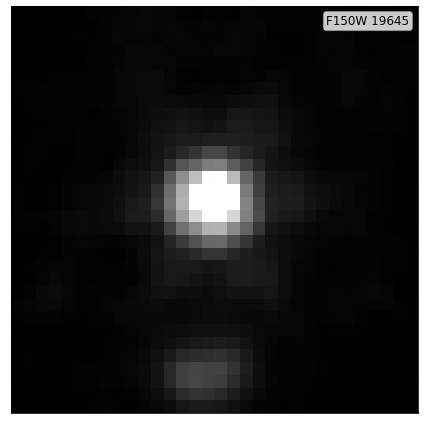

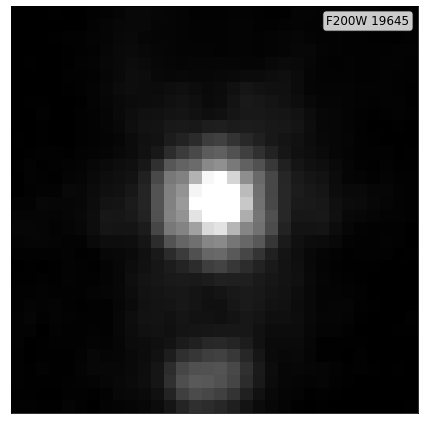

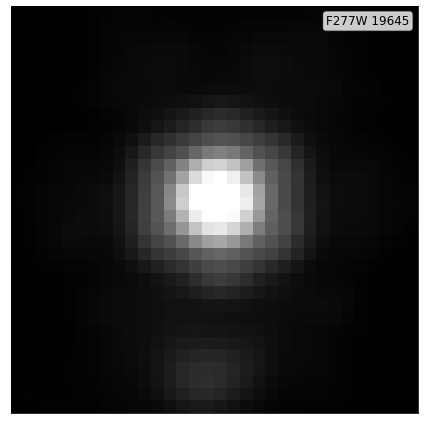

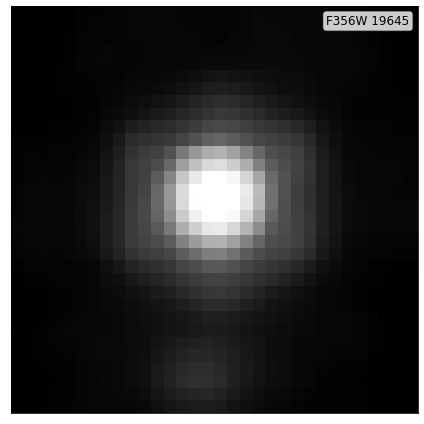

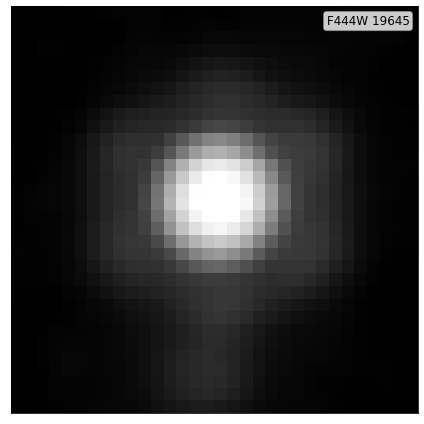

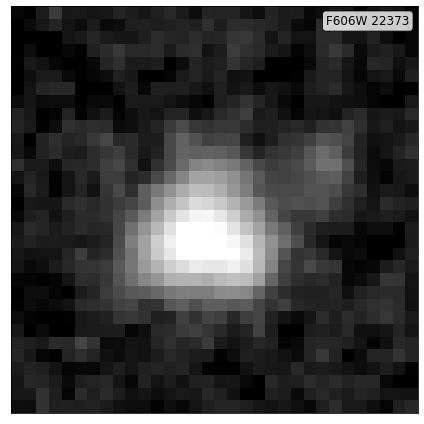

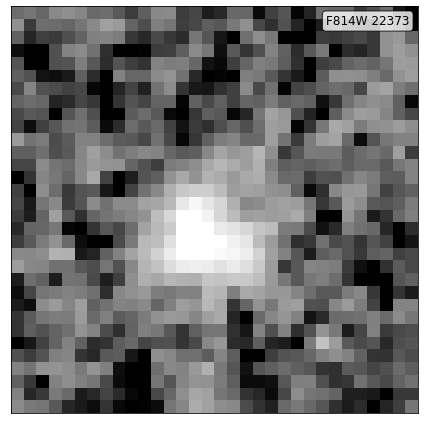

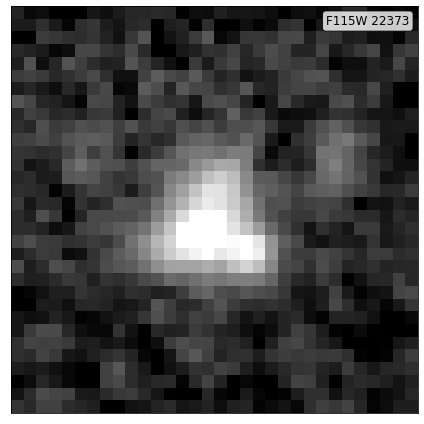

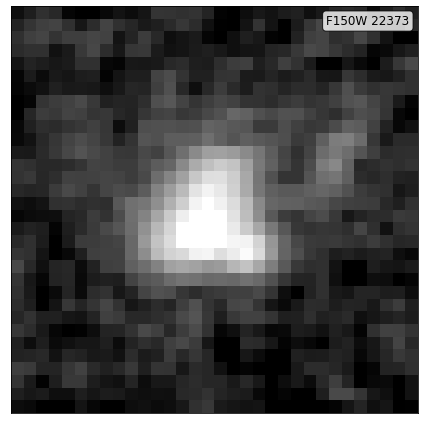

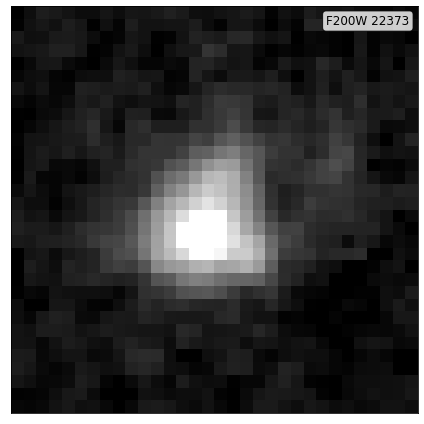

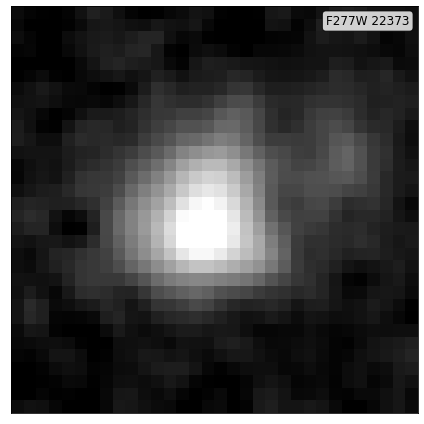

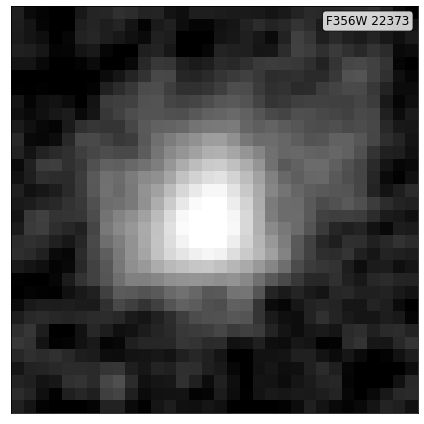

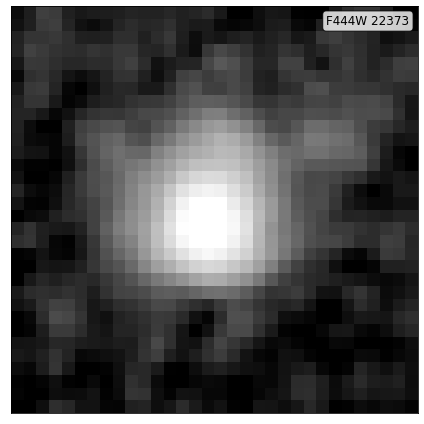

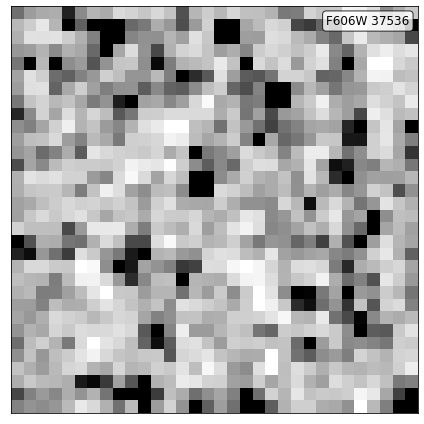

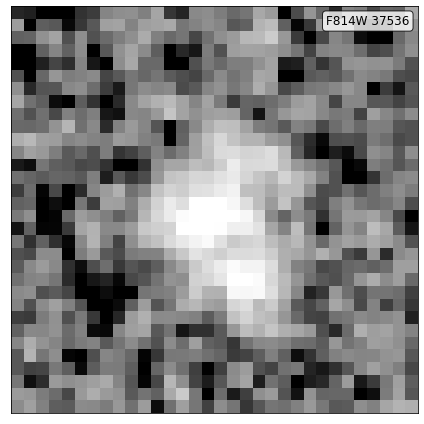

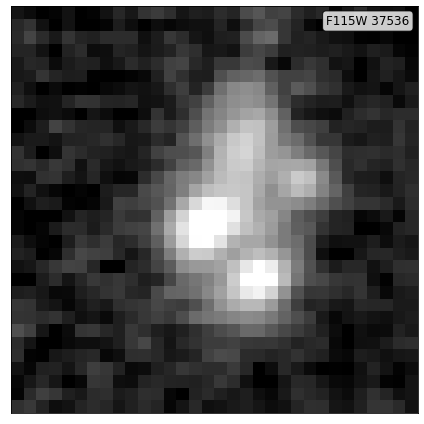

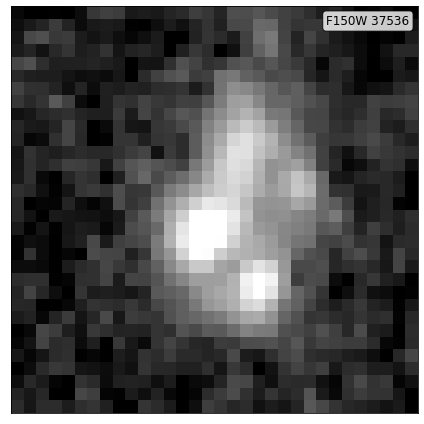

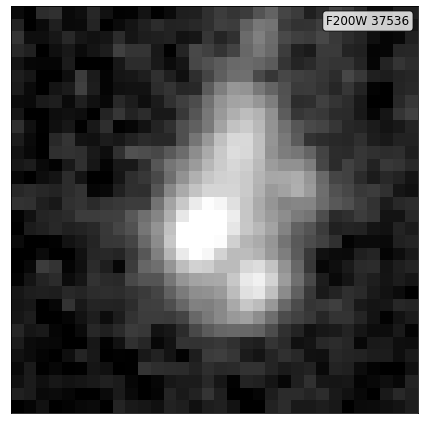

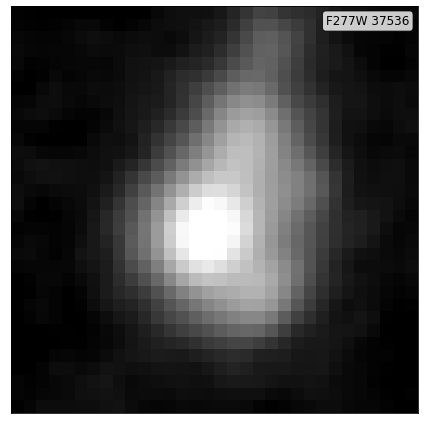

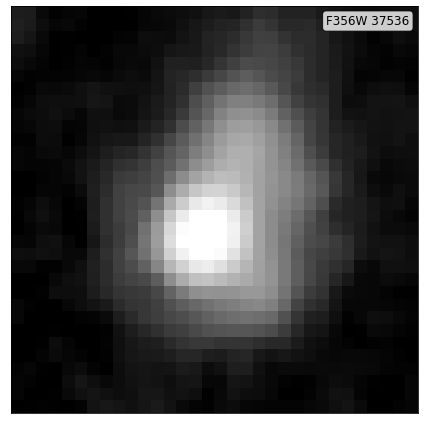

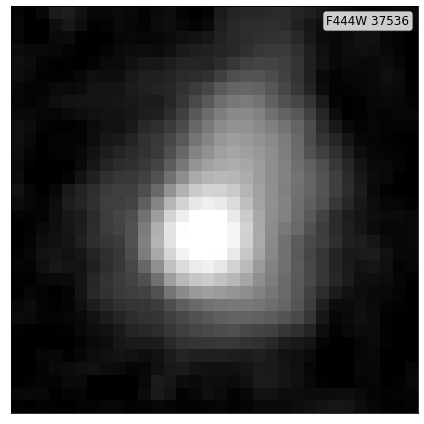

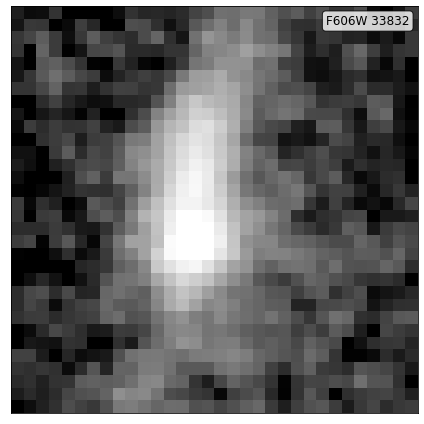

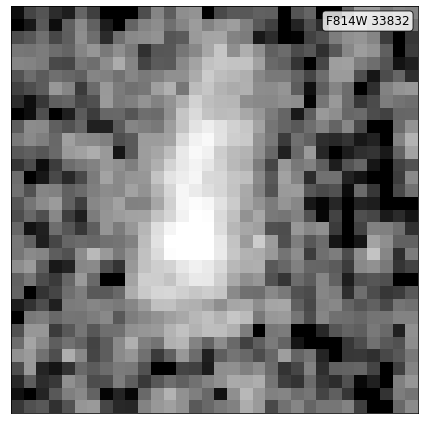

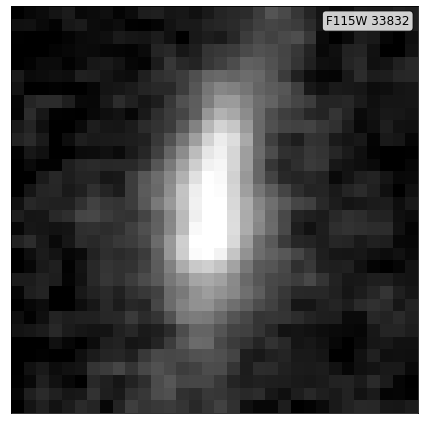

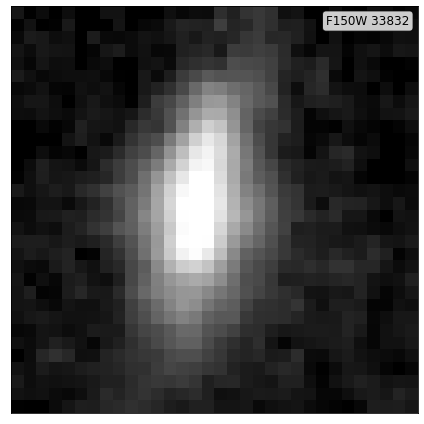

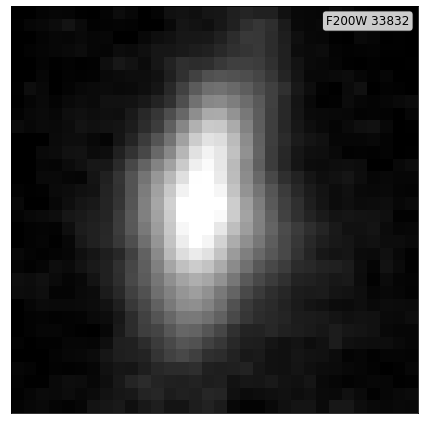

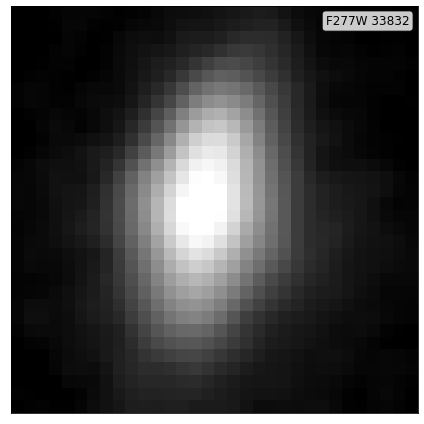

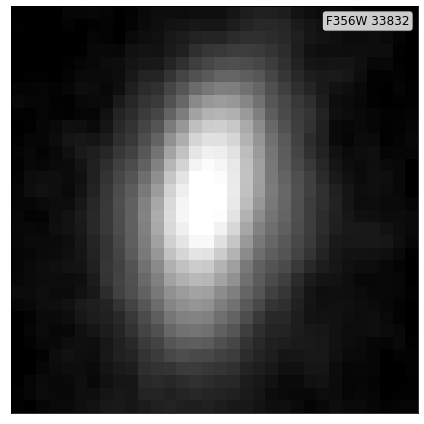

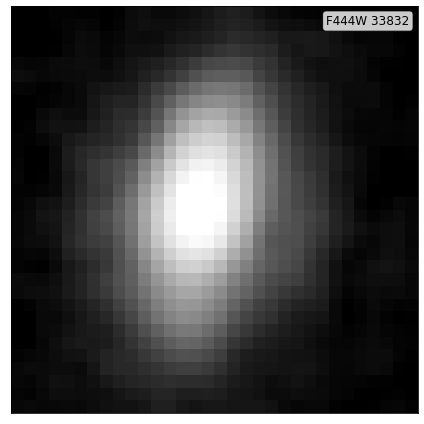

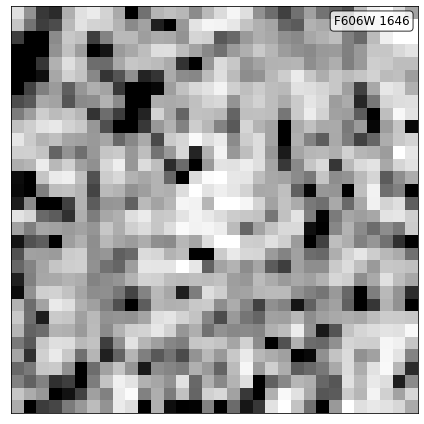

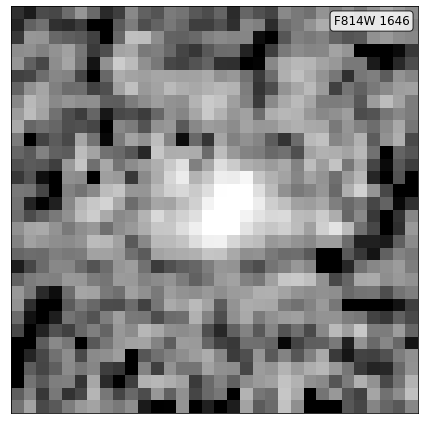

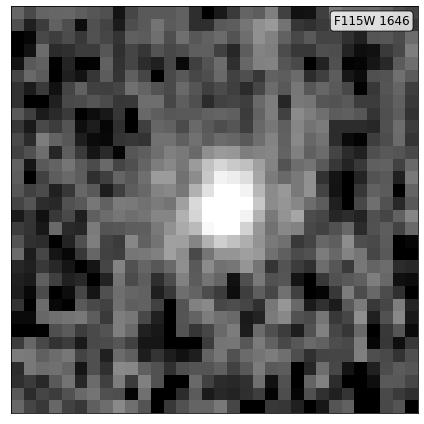

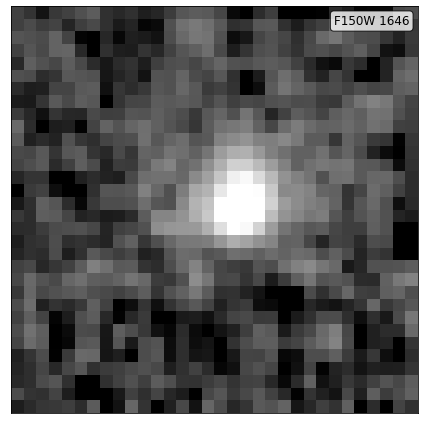

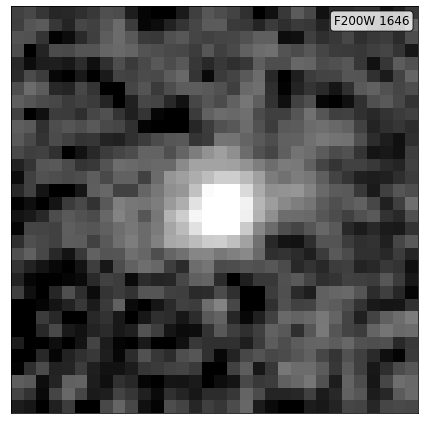

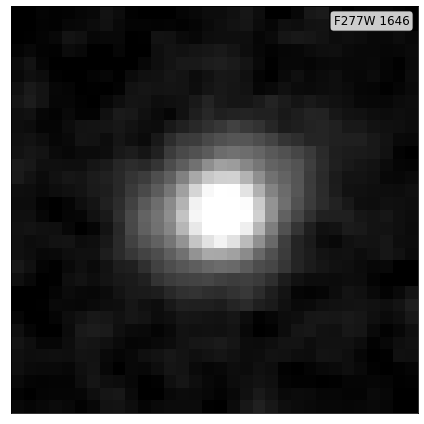

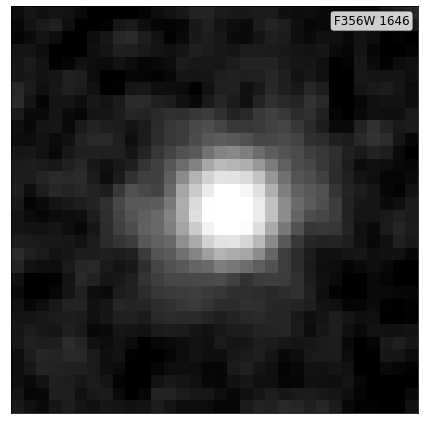

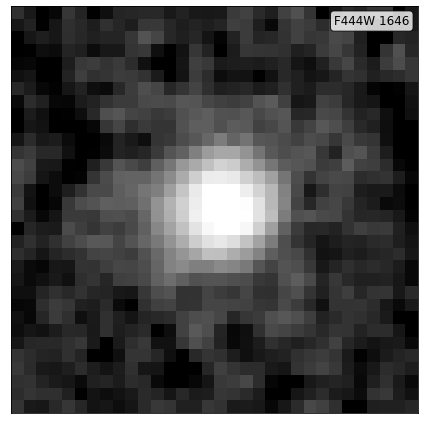

Galaxy 4573 could not be found in these surveys


In [4]:
if __name__ == "__main__":

    cutout_plot(BROAD_LINE_DATA_PATH)